# Makine Öğrenmesi Portfolyosu

### ***Amaç***

Bu notebook, `Specialize in Data Science` Streamlit portfolyosundaki projeler için
veri indirme, ön işleme, eğitim ve **gerçek test-seti değerlendirmesini** tek bir yerde toplar.

***İçindekiler***

1. Regresyon Modelleri — Altın, Öğrenci, Uber
2. Sınıflandırma Modelleri — Mobil, Şarap, Churn
3. Kümeleme Modelleri — NBA, Kredi Kartı, Spotify
4. Görüntü Sınıflandırma — Maske Tespiti
5. NLP Modelleri — SMS Spam, IMDb, Sahte Haber
6. Öneri Sistemleri— Film, Kitap, Şarkı
7. Zaman Serisi Modelleri — Hisse, Hava Durumu, Mağaza Satışı
8. Veri Görselleştirme Setleri — Sosyal Medya, CO2, E-Ticaret
9. Derin Öğrenme (CNN) — Zatürre, Yüz Duygu Tanıma
10. Metin Üretim Robotu


***Özet: Tüm Model Performansları***

#### Gerekli Paketler

In [13]:
!pip install kagglehub pandas numpy scikit-learn joblib opencv-python tensorflow mediapipe yfinance matplotlib

#### ***Kurulum: Ortak Importlar, Metrik Sözlüğü ve Yardımcı Fonksiyonlar***

In [14]:
import os
import json
import pandas as pd
import numpy as np
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import shuffle as sk_shuffle
import joblib

os.makedirs('models', exist_ok=True)
print("📦 Kurulum tamamlandı. Modeller 'models/' klasörüne kaydedilecek.\n")

# ====================================================================
# 🏆 TÜM PROJELERİN GERÇEK BAŞARI PUANLARININ TOPLANACAĞI SÖZLÜK
# Her bölüm sonunda models/metrics.json dosyasına ARA KAYDEDİLİR.
# ====================================================================
metrics = {}

def save_metrics():
    with open('models/metrics.json', 'w', encoding='utf-8') as f:
        json.dump(metrics, f, ensure_ascii=False, indent=2)

def add_regression_metrics(key, y_true, y_pred, unit=""):
    metrics[key] = {
        "type": "regression",
        "R2": round(float(r2_score(y_true, y_pred)), 4),
        "RMSE": round(float(np.sqrt(mean_squared_error(y_true, y_pred))), 4),
        "MAE": round(float(mean_absolute_error(y_true, y_pred)), 4),
        "unit": unit,
    }

def add_classification_metrics(key, y_true, y_pred):
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    metrics[key] = {
        "type": "classification",
        "Accuracy": round(float(accuracy_score(y_true, y_pred)), 4),
        "Precision": round(float(precision_score(y_true, y_pred, average="weighted", zero_division=0)), 4),
        "Recall": round(float(recall_score(y_true, y_pred, average="weighted", zero_division=0)), 4),
        "F1": round(float(f1_score(y_true, y_pred, average="weighted", zero_division=0)), 4),
    }

def add_clustering_metrics(key, X_scaled, labels, n_clusters):
    from sklearn.metrics import silhouette_score
    metrics[key] = {
        "type": "clustering",
        "Silhouette": round(float(silhouette_score(X_scaled, labels)), 4),
        "n_clusters": n_clusters,
    }

def add_deep_learning_metrics(key, history):
    metrics[key] = {
        "type": "deep_learning",
        "Accuracy": round(float(history.history["accuracy"][-1]), 4),
        "Val_Accuracy": round(float(history.history.get("val_accuracy", history.history["accuracy"])[-1]), 4),
        "Loss": round(float(history.history["loss"][-1]), 4),
    }

def add_none_metric(key, note):
    metrics[key] = {"type": "none", "note": note}

def add_error_metric(key, error):
    metrics[key] = {"type": "error", "error": str(error)}
    print(f"❌ {key}: hata oluştu -> {error}")


# ====================================================================
# 🔧 İYİLEŞTİRME: Model yorumlanabilirliği için yardımcı fonksiyonlar
# ====================================================================
def show_classification_report(label, y_true, y_pred, target_names=None):
    print(f"\n🔎 {label} — Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print(f"\n🔎 {label} — Classification Report:")
    print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))

def show_feature_importance(model, feature_names, top_n=5):
    importances = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)
    print(f"\n🔎 Özellik Önemleri (Top {top_n}):")
    display(importances.head(top_n).to_frame("Önem"))


# ====================================================================
# 🔍 VERİ KEŞFİ VE YERİNDE TEMİZLİĞİ (EDA) YARDIMCI FONKSİYONLARI
# Notebook içindeki mevcut değişken adlarını değiştirmeniz GEREKMEZ.
# ====================================================================
def explore_dataset(df, name):
    print(f"\n{'='*65}")
    print(f"📊 VERİ SETİ İNCELEMESİ VE TEMİZLİĞİ: {name}")
    print(f"{'='*65}")

    print(f"\n🔹 Shape (satır, sütun): {df.shape}")

    print(f"\n🔹 İlk 5 satır:")
    display(df.head())

    print(f"\n🔹 info():")
    df.info()

    print(f"\n🔹 Eksik değerler (isnull().sum()):")
    null_counts = df.isnull().sum()
    null_counts = null_counts[null_counts > 0]

    if len(null_counts) > 0:
        display(null_counts.to_frame("Eksik Değer Sayısı"))
        print("\n⚠️ Eksik satırlar yerinde (inplace) temizleniyor...")

        # Orijinal satır sayısını kaydet
        eski_satir_sayisi = len(df)

        # inplace=True ile hücre dışındaki orijinal df'i doğrudan günceller
        df.dropna(inplace=True)
        df.reset_index(drop=True, inplace=True)

        silinen_satir = eski_satir_sayisi - len(df)
        print(f"   ✅ Toplam {silinen_satir} adet eksik satır silindi.")
        print(f"   🔹 Yeni Shape (satır, sütun): {df.shape}")
    else:
        print("   ✅ Eksik değer yok.")

    print(f"\n🔹 describe() (sayısal sütunlar):")
    display(df.describe())
    print(f"{'='*65}\n")


def explore_array(X, y, name, class_names=None):
    # Not: NumPy dizileri (array) yapıları gereği 'inplace' silme işlemini desteklemez.
    # Ancak Python'ın 'global' anahtar kelimesi ile notebook'taki orijinal değişkenleri güncelleyebiliriz.
    global X_global_ref, y_global_ref

    print(f"\n{'='*65}")
    print(f"📊 VERİ SETİ İNCELEMESİ VE TEMİZLİĞİ (görüntü/dizi): {name}")
    print(f"{'='*65}")
    print(f"\n🔹 X şekli (shape): {X.shape}")
    print(f"🔹 y şekli (shape): {y.shape}")

    if np.isnan(X).any() or np.isnan(y).any():
        print("\n⚠️ Dizilerde eksik değerler (NaN) tespit edildi. Temizleniyor...")

        # NaN olmayan satırların maskesini çıkart
        X_flat = X.reshape(X.shape[0], -1)
        valid_X_mask = ~np.isnan(X_flat).any(axis=1)

        if y.ndim > 1:
            y_flat = y.reshape(y.shape[0], -1)
            valid_y_mask = ~np.isnan(y_flat).any(axis=1)
        else:
            valid_y_mask = ~np.isnan(y)

        valid_mask = valid_X_mask & valid_y_mask

        eski_X_boyut = X.shape[0]

        # Orijinal array verisini dilimleme (slice) yöntemiyle yerinde değiştiriyoruz
        # Bu yöntem hücre dışındaki değişkenin de güncellenmesini sağlar
        X_yeni = X[valid_mask]
        y_yeni = y[valid_mask]

        silinen_ornek = eski_X_boyut - X_yeni.shape[0]
        print(f"   ✅ Toplam {silinen_ornek} adet eksik örnek temizlendi.")

        print(
            "   ⚠️ UYARI: NumPy doğası gereği array temizliğinde eski değişken adını kullanmaya devam etmek için"
        )
        print(
            f"   kodu şu şekilde çağırın: X, y = explore_array(X, y, '{name}')"
        )
    else:
        print("   ✅ Eksik değer yok.")
        X_yeni, y_yeni = X, y

    unique, counts = np.unique(y_yeni, return_counts=True)
    print(f"\n🔹 Sınıf dağılımı:")
    for cls, cnt in zip(unique, counts):
        label = class_names[cls] if class_names else cls
        print(f"   {label}: {cnt} örnek")
    print(f"{'='*65}\n")

    return X_yeni, y_yeni


📦 Kurulum tamamlandı. Modeller 'models/' klasörüne kaydedilecek.



##  ***1-Regresyon Modelleri***

###  *Altın Fiyatı Tahmini*

> **📌 Amaç:** GLD altın ETF fiyatını SPX, USO, SLV ve EUR/USD göstergelerinden tahmin etmek.  
> **📂 Veri Seti:** Kaggle `gold-price-data`  
> **🧠 Model:** RandomForestRegressor + RandomizedSearchCV  
> **📊 Değerlendirme:** R², RMSE, MAE

In [15]:
try:
    print("🪙 Altın Fiyatı Modeli Eğitiliyor...")
    gold_path = kagglehub.dataset_download("altruistdelhite04/gold-price-data")
    gold_df = pd.read_csv(os.path.join(gold_path, "gld_price_data.csv"))
    explore_dataset(gold_df, "Altın Fiyatı (GLD)")

    X_gold = gold_df.drop(['Date', 'GLD'], axis=1)
    y_gold = gold_df['GLD']

    X_tr_g, X_te_g, y_tr_g, y_te_g = train_test_split(X_gold, y_gold, test_size=0.2, random_state=42)

    param_grid_gold = {'n_estimators': [100, 200], 'max_depth': [None, 10, 20], 'min_samples_leaf': [1, 2]}
    search_gold = RandomizedSearchCV(RandomForestRegressor(random_state=42), param_grid_gold,
                                      n_iter=5, cv=5, random_state=42, n_jobs=-1)
    search_gold.fit(X_tr_g, y_tr_g)
    gold_model = search_gold.best_estimator_
    joblib.dump(gold_model, 'models/gold_model.pkl')

    y_pred_gold = gold_model.predict(X_te_g)
    add_regression_metrics("gold", y_te_g, y_pred_gold, unit="$")
    metrics["gold"]["CV_R2"] = round(float(search_gold.best_score_), 4)
    metrics["gold"]["best_params"] = search_gold.best_params_
    print(f"   📊 R²={metrics['gold']['R2']}  RMSE={metrics['gold']['RMSE']}  MAE={metrics['gold']['MAE']}")
    print(f"   🔧 En iyi parametreler: {search_gold.best_params_}  (5-fold CV R²={metrics['gold']['CV_R2']})")
    show_feature_importance(gold_model, X_gold.columns)
    print("✅ Altın modeli kaydedildi: models/gold_model.pkl\n")
except Exception as e:
    add_error_metric("gold", e)

🪙 Altın Fiyatı Modeli Eğitiliyor...
Using Colab cache for faster access to the 'gold-price-data' dataset.

📊 VERİ SETİ İNCELEMESİ VE TEMİZLİĞİ: Altın Fiyatı (GLD)

🔹 Shape (satır, sütun): (2290, 6)

🔹 İlk 5 satır:


,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099



🔹 info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB

🔹 Eksik değerler (isnull().sum()):
   ✅ Eksik değer yok.

🔹 describe() (sayısal sütunlar):


,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798



   📊 R²=0.9904  RMSE=2.2916  MAE=1.2252
   🔧 En iyi parametreler: {'n_estimators': 200, 'min_samples_leaf': 1, 'max_depth': 20}  (5-fold CV R²=0.9886)

🔎 Özellik Önemleri (Top 5):


,Önem
SLV,0.763637
SPX,0.174549
USO,0.034929
EUR/USD,0.026885


✅ Altın modeli kaydedildi: models/gold_model.pkl



### *Öğrenci Sınav Puanı Tahmini*

> **📌 Amaç:** Öğrencinin matematik sınav puanını demografik ve hazırlık faktörlerinden tahmin etmek.  
> **📂 Veri Seti:** `StudentsPerformance`  
> **🧠 Model:** RandomForestRegressor + RandomizedSearchCV  
> **📊 Değerlendirme:** R², RMSE, MAE

In [16]:
try:
    print("📝 Öğrenci Sınav Puanı Modeli Eğitiliyor...")
    student_path = kagglehub.dataset_download("spscientist/students-performance-in-exams")
    student_df = pd.read_csv(os.path.join(student_path, "StudentsPerformance.csv"))
    explore_dataset(student_df, "Öğrenci Sınav Performansı")

    student_df = pd.get_dummies(student_df, columns=[
        'gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course'
    ], drop_first=True)

    X_student = student_df.drop(['math score'], axis=1)
    y_student = student_df['math score']

    X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(X_student, y_student, test_size=0.2, random_state=42)

    param_grid_student = {'n_estimators': [100, 200], 'max_depth': [None, 10, 20], 'min_samples_leaf': [1, 2]}
    search_student = RandomizedSearchCV(RandomForestRegressor(random_state=42), param_grid_student,
                                         n_iter=5, cv=5, random_state=42, n_jobs=-1)
    search_student.fit(X_tr_s, y_tr_s)
    student_model = search_student.best_estimator_
    joblib.dump(student_model, 'models/student_model.pkl')

    y_pred_student = student_model.predict(X_te_s)
    add_regression_metrics("student", y_te_s, y_pred_student, unit="puan")
    metrics["student"]["CV_R2"] = round(float(search_student.best_score_), 4)
    metrics["student"]["best_params"] = search_student.best_params_
    print(f"   📊 R²={metrics['student']['R2']}  RMSE={metrics['student']['RMSE']}  MAE={metrics['student']['MAE']}")
    print(f"   🔧 En iyi parametreler: {search_student.best_params_}  (5-fold CV R²={metrics['student']['CV_R2']})")
    show_feature_importance(student_model, X_student.columns)
    print("✅ Öğrenci puan modeli kaydedildi: models/student_model.pkl\n")
except Exception as e:
    add_error_metric("student", e)

📝 Öğrenci Sınav Puanı Modeli Eğitiliyor...
Using Colab cache for faster access to the 'students-performance-in-exams' dataset.

📊 VERİ SETİ İNCELEMESİ VE TEMİZLİĞİ: Öğrenci Sınav Performansı

🔹 Shape (satır, sütun): (1000, 8)

🔹 İlk 5 satır:


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75



🔹 info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB

🔹 Eksik değerler (isnull().sum()):
   ✅ Eksik değer yok.

🔹 describe() (sayısal sütunlar):


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000



   📊 R²=0.8489  RMSE=6.0646  MAE=4.7104
   🔧 En iyi parametreler: {'n_estimators': 100, 'min_samples_leaf': 2, 'max_depth': 20}  (5-fold CV R²=0.8373)

🔎 Özellik Önemleri (Top 5):


,Önem
reading score,0.572882
writing score,0.235378
gender_male,0.124503
lunch_standard,0.014813
test preparation course_none,0.010420


✅ Öğrenci puan modeli kaydedildi: models/student_model.pkl



### *Uber/Taksi Ücret Tahmini*

> **📌 Amaç:** Uber/taksi yolculuk ücretini kalkış-varış koordinatları ve yolcu sayısından tahmin etmek.  
> **📂 Veri Seti:** `uber-fares-dataset` (aykırı değer/outlier temizliği uygulanmıştır)  
> **🧠 Model:** RandomForestRegressor + RandomizedSearchCV  
> **📊 Değerlendirme:** R², RMSE, MAE

In [17]:
try:
    print("🚗 Uber/Taksi Ücret Modeli Eğitiliyor...")
    uber_path = kagglehub.dataset_download("yasserh/uber-fares-dataset")
    uber_df = pd.read_csv(os.path.join(uber_path, "uber.csv"))
    explore_dataset(uber_df, "Uber Fares (ham)")

    uber_df = uber_df.dropna()
    uber_df = uber_df[
        (uber_df['fare_amount'].between(2.5, 200)) &
        (uber_df['pickup_longitude'].between(-75, -72)) &
        (uber_df['pickup_latitude'].between(40, 42)) &
        (uber_df['dropoff_longitude'].between(-75, -72)) &
        (uber_df['dropoff_latitude'].between(40, 42)) &
        (uber_df['passenger_count'].between(1, 6))
    ]

    X_uber = uber_df[['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count']]
    y_uber = uber_df['fare_amount']

    X_tr_u, X_te_u, y_tr_u, y_te_u = train_test_split(X_uber[:50000], y_uber[:50000], test_size=0.2, random_state=42)

    param_grid_uber = {'n_estimators': [50, 100], 'max_depth': [None, 10, 15], 'min_samples_leaf': [1, 2]}
    search_uber = RandomizedSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1), param_grid_uber,
                                      n_iter=4, cv=3, random_state=42, n_jobs=-1)
    search_uber.fit(X_tr_u, y_tr_u)
    uber_model = search_uber.best_estimator_
    joblib.dump(uber_model, 'models/uber_model.pkl')

    y_pred_uber = uber_model.predict(X_te_u)
    add_regression_metrics("uber", y_te_u, y_pred_uber, unit="$")
    metrics["uber"]["CV_R2"] = round(float(search_uber.best_score_), 4)
    metrics["uber"]["best_params"] = search_uber.best_params_
    print(f"   📊 R²={metrics['uber']['R2']}  RMSE={metrics['uber']['RMSE']}  MAE={metrics['uber']['MAE']}")
    print(f"   🔧 En iyi parametreler: {search_uber.best_params_}  (3-fold CV R²={metrics['uber']['CV_R2']})")
    show_feature_importance(uber_model, X_uber.columns)
    print("✅ Uber ücret modeli kaydedildi: models/uber_model.pkl\n")
except Exception as e:
    add_error_metric("uber", e)

save_metrics()
print("🎉 Regresyon bölümü tamamlandı, metrics.json ara kaydedildi.")

🚗 Uber/Taksi Ücret Modeli Eğitiliyor...
Using Colab cache for faster access to the 'uber-fares-dataset' dataset.

📊 VERİ SETİ İNCELEMESİ VE TEMİZLİĞİ: Uber Fares (ham)

🔹 Shape (satır, sütun): (200000, 9)

🔹 İlk 5 satır:


,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5



🔹 info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB

🔹 Eksik değerler (isnull().sum()):


,Eksik Değer Sayısı
dropoff_longitude,1
dropoff_latitude,1



⚠️ Eksik satırlar yerinde (inplace) temizleniyor...
   ✅ Toplam 1 adet eksik satır silindi.
   🔹 Yeni Shape (satır, sütun): (199999, 9)

🔹 describe() (sayısal sütunlar):


,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,1.999990e+05,199999.000000,199999.000000,199999.000000,199999.000000,199999.000000,199999.000000
mean,2.771248e+07,11.359892,-72.527631,39.935881,-72.525292,39.923890,1.684543
std,1.601386e+07,9.901760,11.437815,7.720558,13.117408,6.794829,1.385995
min,1.000000e+00,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.382534e+07,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,2.774524e+07,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,4.155535e+07,12.500000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,5.542357e+07,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000



   📊 R²=0.7775  RMSE=4.6446  MAE=2.2872
   🔧 En iyi parametreler: {'n_estimators': 50, 'min_samples_leaf': 1, 'max_depth': None}  (3-fold CV R²=0.7859)

🔎 Özellik Önemleri (Top 5):


,Önem
dropoff_longitude,0.386004
pickup_longitude,0.331804
dropoff_latitude,0.155003
pickup_latitude,0.119067
passenger_count,0.008122


✅ Uber ücret modeli kaydedildi: models/uber_model.pkl

🎉 Regresyon bölümü tamamlandı, metrics.json ara kaydedildi.


## ***2-Sınıflandırma Modelleri***

### *Mobil Cihaz Fiyat Segmenti*

> **📌 Amaç:** Telefonun donanım özelliklerinden fiyat segmentini (0–3) sınıflandırmak.  
> **📂 Veri Seti:** `mobile-price-classification`  
> **🧠 Model:** RandomForestClassifier + RandomizedSearchCV  
> **📊 Değerlendirme:** Accuracy, F1

In [18]:
from sklearn.ensemble import RandomForestClassifier

try:
    print("📱 Mobil Cihaz Fiyat Segmenti Modeli Eğitiliyor...")
    mobile_path = kagglehub.dataset_download("iabhishekofficial/mobile-price-classification")
    mobile_df = pd.read_csv(os.path.join(mobile_path, "train.csv"))
    explore_dataset(mobile_df, "Mobil Cihaz Fiyat Sınıflandırması")

    features_mobile = ['battery_power', 'clock_speed', 'dual_sim', 'int_memory', 'm_dep',
                        'mobile_wt', 'n_cores', 'pc', 'ram', 'touch_screen', 'wifi']
    X_mobile = mobile_df[features_mobile]
    y_mobile = mobile_df['price_range']

    X_tr_m, X_te_m, y_tr_m, y_te_m = train_test_split(X_mobile, y_mobile, test_size=0.2, random_state=42)

    param_grid_mobile = {'n_estimators': [100, 200], 'max_depth': [None, 10, 20], 'min_samples_leaf': [1, 2]}
    search_mobile = RandomizedSearchCV(RandomForestClassifier(random_state=42), param_grid_mobile,
                                        n_iter=5, cv=5, random_state=42, n_jobs=-1)
    search_mobile.fit(X_tr_m, y_tr_m)
    mobile_model = search_mobile.best_estimator_
    joblib.dump(mobile_model, 'models/mobile_model.pkl')

    y_pred_mobile = mobile_model.predict(X_te_m)
    add_classification_metrics("mobile", y_te_m, y_pred_mobile)
    metrics["mobile"]["CV_Accuracy"] = round(float(search_mobile.best_score_), 4)
    metrics["mobile"]["best_params"] = search_mobile.best_params_
    print(f"   📊 Accuracy={metrics['mobile']['Accuracy']}  F1={metrics['mobile']['F1']}")
    print(f"   🔧 En iyi parametreler: {search_mobile.best_params_}  (5-fold CV Accuracy={metrics['mobile']['CV_Accuracy']})")
    show_feature_importance(mobile_model, features_mobile)
    show_classification_report("Mobil Fiyat Segmenti", y_te_m, y_pred_mobile)
    print("✅ Mobil modeli kaydedildi: models/mobile_model.pkl\n")
except Exception as e:
    add_error_metric("mobile", e)

📱 Mobil Cihaz Fiyat Segmenti Modeli Eğitiliyor...
Using Colab cache for faster access to the 'mobile-price-classification' dataset.

📊 VERİ SETİ İNCELEMESİ VE TEMİZLİĞİ: Mobil Cihaz Fiyat Sınıflandırması

🔹 Shape (satır, sütun): (2000, 21)

🔹 İlk 5 satır:


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1



🔹 info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 1

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000



   📊 Accuracy=0.8125  F1=0.8142
   🔧 En iyi parametreler: {'n_estimators': 100, 'min_samples_leaf': 2, 'max_depth': 20}  (5-fold CV Accuracy=0.8069)

🔎 Özellik Önemleri (Top 5):


,Önem
ram,0.609612
battery_power,0.108700
mobile_wt,0.054147
int_memory,0.052517
pc,0.041113



🔎 Mobil Fiyat Segmenti — Confusion Matrix:
[[98  7  0  0]
 [ 9 70 12  0]
 [ 0 13 68 11]
 [ 0  0 23 89]]

🔎 Mobil Fiyat Segmenti — Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.93      0.92       105
           1       0.78      0.77      0.77        91
           2       0.66      0.74      0.70        92
           3       0.89      0.79      0.84       112

    accuracy                           0.81       400
   macro avg       0.81      0.81      0.81       400
weighted avg       0.82      0.81      0.81       400

✅ Mobil modeli kaydedildi: models/mobile_model.pkl



### *Kırmızı Şarap Kalitesi Sınıflandırması*

> **📌 Amaç:** Kimyasal özelliklerden kırmızı şarap kalite puanını (3–8) sınıflandırmak.  
> **📂 Veri Seti:** `red-wine-quality`  
> **🧠 Model:** RandomForestClassifier (`class_weight='balanced'`)  
> **📊 Değerlendirme:** Accuracy, F1

In [19]:
from sklearn.ensemble import RandomForestClassifier

try:
    print("🍷 Şarap Kalitesi Modeli Eğitiliyor...")
    wine_path = kagglehub.dataset_download("uciml/red-wine-quality-cortez-et-al-2009")
    wine_df = pd.read_csv(os.path.join(wine_path, "winequality-red.csv"))
    explore_dataset(wine_df, "Kırmızı Şarap Kalitesi")

    X_wine = wine_df.drop(['quality'], axis=1)
    y_wine = wine_df['quality']

    X_tr_w, X_te_w, y_tr_w, y_te_w = train_test_split(X_wine, y_wine, test_size=0.2, random_state=42)

    param_grid_wine = {'n_estimators': [200, 300], 'max_depth': [None, 20, 30], 'min_samples_leaf': [1, 2]}
    search_wine = RandomizedSearchCV(RandomForestClassifier(random_state=42, class_weight='balanced'), param_grid_wine,
                                      n_iter=5, cv=5, random_state=42, n_jobs=-1)
    search_wine.fit(X_tr_w, y_tr_w)
    wine_model = search_wine.best_estimator_
    joblib.dump(wine_model, 'models/wine_model.pkl')

    y_pred_wine = wine_model.predict(X_te_w)
    add_classification_metrics("wine", y_te_w, y_pred_wine)
    metrics["wine"]["CV_Accuracy"] = round(float(search_wine.best_score_), 4)
    metrics["wine"]["best_params"] = search_wine.best_params_
    print(f"   📊 Accuracy={metrics['wine']['Accuracy']}  F1={metrics['wine']['F1']}")
    print(f"   🔧 En iyi parametreler: {search_wine.best_params_}  (5-fold CV Accuracy={metrics['wine']['CV_Accuracy']})")
    show_feature_importance(wine_model, X_wine.columns)
    show_classification_report("Şarap Kalitesi", y_te_w, y_pred_wine)
    print("✅ Şarap kalitesi modeli kaydedildi: models/wine_model.pkl\n")
except Exception as e:
    add_error_metric("wine", e)


🍷 Şarap Kalitesi Modeli Eğitiliyor...
Using Colab cache for faster access to the 'red-wine-quality-cortez-et-al-2009' dataset.

📊 VERİ SETİ İNCELEMESİ VE TEMİZLİĞİ: Kırmızı Şarap Kalitesi

🔹 Shape (satır, sütun): (1599, 12)

🔹 İlk 5 satır:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5



🔹 info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB

🔹 Eksik değerler (isnull().sum()):
   ✅ Eksik değer yok.

🔹 describe() (sayısal sütunlar):


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000



   📊 Accuracy=0.675  F1=0.6562
   🔧 En iyi parametreler: {'n_estimators': 300, 'min_samples_leaf': 1, 'max_depth': 20}  (5-fold CV Accuracy=0.6896)

🔎 Özellik Önemleri (Top 5):


,Önem
alcohol,0.129526
volatile acidity,0.126958
sulphates,0.126234
chlorides,0.096141
total sulfur dioxide,0.088653



🔎 Şarap Kalitesi — Confusion Matrix:
[[  0   0   1   0   0   0]
 [  0   0   6   4   0   0]
 [  0   0 102  28   0   0]
 [  0   0  33  93   6   0]
 [  0   0   0  20  21   1]
 [  0   0   0   0   5   0]]

🔎 Şarap Kalitesi — Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.72      0.78      0.75       130
           6       0.64      0.70      0.67       132
           7       0.66      0.50      0.57        42
           8       0.00      0.00      0.00         5

    accuracy                           0.68       320
   macro avg       0.34      0.33      0.33       320
weighted avg       0.64      0.68      0.66       320

✅ Şarap kalitesi modeli kaydedildi: models/wine_model.pkl



### *Telekom Müşteri Terki (Churn) Analizi*

> **📌 Amaç:** Telekom müşterisinin abonelikten ayrılıp ayrılmayacağını (churn) tahmin etmek.  
> **📂 Veri Seti:** `telco-customer-churn` (tüm kategorik özellikler one-hot kodlanmıştır)  
> **🧠 Model:** RandomForestClassifier (`class_weight='balanced'`)  
> **📊 Değerlendirme:** Accuracy, F1

In [20]:
try:
    print("🚀 Müşteri Terki Modeli Eğitiliyor...")
    churn_path = kagglehub.dataset_download("blastchar/telco-customer-churn")
    churn_df = pd.read_csv(os.path.join(churn_path, "WA_Fn-UseC_-Telco-Customer-Churn.csv"))
    explore_dataset(churn_df, "Telco Müşteri Terki (ham)")

    churn_df['TotalCharges'] = pd.to_numeric(churn_df['TotalCharges'], errors='coerce')
    churn_df = churn_df.dropna()

    churn_df['gender'] = churn_df['gender'].map({'Female': 0, 'Male': 1})
    churn_df['Partner'] = churn_df['Partner'].map({'No': 0, 'Yes': 1})
    churn_df['Dependents'] = churn_df['Dependents'].map({'No': 0, 'Yes': 1})
    churn_df['PhoneService'] = churn_df['PhoneService'].map({'No': 0, 'Yes': 1})
    churn_df['Churn'] = churn_df['Churn'].map({'No': 0, 'Yes': 1})

    cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                'Contract', 'PaperlessBilling', 'PaymentMethod']
    churn_df = pd.get_dummies(churn_df, columns=cat_cols, drop_first=True)

    features_churn = [c for c in churn_df.columns if c != 'Churn' and c != 'customerID']
    X_churn = churn_df[features_churn]
    y_churn = churn_df['Churn']

    X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(X_churn, y_churn, test_size=0.2, random_state=42)


    param_grid_churn = {'n_estimators': [100, 200], 'max_depth': [None, 10, 20], 'min_samples_leaf': [1, 2]}
    search_churn = RandomizedSearchCV(
        RandomForestClassifier(random_state=42, class_weight='balanced'), param_grid_churn,
        n_iter=5, cv=5, random_state=42, n_jobs=-1)
    search_churn.fit(X_tr_c, y_tr_c)
    churn_model = search_churn.best_estimator_
    joblib.dump(churn_model, 'models/churn_model.pkl')

    y_pred_churn = churn_model.predict(X_te_c)
    add_classification_metrics("churn", y_te_c, y_pred_churn)
    metrics["churn"]["CV_Accuracy"] = round(float(search_churn.best_score_), 4)
    metrics["churn"]["best_params"] = search_churn.best_params_
    print(f"   📊 Accuracy={metrics['churn']['Accuracy']}  F1={metrics['churn']['F1']}")
    print(f"   🔧 En iyi parametreler: {search_churn.best_params_}  (5-fold CV Accuracy={metrics['churn']['CV_Accuracy']})")
    show_feature_importance(churn_model, features_churn)
    show_classification_report("Müşteri Terki", y_te_c, y_pred_churn, target_names=["Kalan", "Terk Eden"])
    print("✅ Müşteri terki modeli kaydedildi: models/churn_model.pkl\n")
except Exception as e:
    add_error_metric("churn", e)

save_metrics()
print("🎉 Sınıflandırma bölümü tamamlandı, metrics.json ara kaydedildi.")

🚀 Müşteri Terki Modeli Eğitiliyor...
Using Colab cache for faster access to the 'telco-customer-churn' dataset.

📊 VERİ SETİ İNCELEMESİ VE TEMİZLİĞİ: Telco Müşteri Terki (ham)

🔹 Shape (satır, sütun): (7043, 21)

🔹 İlk 5 satır:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



🔹 info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000



   📊 Accuracy=0.7889  F1=0.7796
   🔧 En iyi parametreler: {'n_estimators': 200, 'min_samples_leaf': 1, 'max_depth': 20}  (5-fold CV Accuracy=0.7991)

🔎 Özellik Önemleri (Top 5):


,Önem
TotalCharges,0.174837
tenure,0.166832
MonthlyCharges,0.149794
Contract_Two year,0.057762
InternetService_Fiber optic,0.043893



🔎 Müşteri Terki — Confusion Matrix:
[[927 106]
 [191 183]]

🔎 Müşteri Terki — Classification Report:
              precision    recall  f1-score   support

       Kalan       0.83      0.90      0.86      1033
   Terk Eden       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407

✅ Müşteri terki modeli kaydedildi: models/churn_model.pkl

🎉 Sınıflandırma bölümü tamamlandı, metrics.json ara kaydedildi.


## ***3-Kümeleme Modelleri***

### *NBA Oyuncu Performans Gruplaması*

> **📌 Amaç:** Oyuncuları sayı-ribaund-asist istatistiklerine göre performans gruplarına ayırmak.  
> **📂 Veri Seti:** `nba-players-data`  
> **🧠 Model:** KMeans (silhouette ile otomatik k seçimi)  
> **📊 Değerlendirme:** Silhouette

In [21]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

try:
    print("🏆 NBA Oyuncu Performans Modeli Eğitiliyor...")
    nba_path = kagglehub.dataset_download("justinas/nba-players-data")
    nba_df = pd.read_csv(os.path.join(nba_path, "all_seasons.csv"))
    explore_dataset(nba_df, "NBA Oyuncu İstatistikleri")

    features_nba = ['pts', 'reb', 'ast']
    X_nba = nba_df[features_nba].dropna()

    scaler_nba = StandardScaler()
    X_nba_scaled = scaler_nba.fit_transform(X_nba)

    # 🔧 İYİLEŞTİRME: sabit n_clusters=4 yerine silhouette skoruna göre otomatik k seçimi
    best_k, best_score, kmeans_nba = None, -1, None
    for k in [3, 4, 5, 6]:
        km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_nba_scaled)
        score = silhouette_score(X_nba_scaled, km.labels_)
        print(f"   k={k}: Silhouette={score:.4f}")
        if score > best_score:
            best_k, best_score, kmeans_nba = k, score, km

    joblib.dump(kmeans_nba, 'models/nba_model.pkl')
    joblib.dump(scaler_nba, 'models/nba_scaler.pkl')

    add_clustering_metrics("nba", X_nba_scaled, kmeans_nba.labels_, n_clusters=best_k)
    print(f"   📊 En iyi k={best_k}  Silhouette={metrics['nba']['Silhouette']}")
    print("✅ NBA modeli ve ölçekleyicisi kaydedildi.\n")
except Exception as e:
    add_error_metric("nba", e)

🏆 NBA Oyuncu Performans Modeli Eğitiliyor...
Using Colab cache for faster access to the 'nba-players-data' dataset.

📊 VERİ SETİ İNCELEMESİ VE TEMİZLİĞİ: NBA Oyuncu İstatistikleri

🔹 Shape (satır, sütun): (12844, 22)

🔹 İlk 5 satır:


,Unnamed: 0,player_name,team_abbreviation,age,player_height,player_weight,college,country,draft_year,draft_round,...,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,season
0,0,Randy Livingston,HOU,22.0,193.04,94.800728,Louisiana State,USA,1996,2,...,3.9,1.5,2.4,0.3,0.042,0.071,0.169,0.487,0.248,1996-97
1,1,Gaylon Nickerson,WAS,28.0,190.50,86.182480,Northwestern Oklahoma,USA,1994,2,...,3.8,1.3,0.3,8.9,0.030,0.111,0.174,0.497,0.043,1996-97
2,2,George Lynch,VAN,26.0,203.20,103.418976,North Carolina,USA,1993,1,...,8.3,6.4,1.9,-8.2,0.106,0.185,0.175,0.512,0.125,1996-97
3,3,George McCloud,LAL,30.0,203.20,102.058200,Florida State,USA,1989,1,...,10.2,2.8,1.7,-2.7,0.027,0.111,0.206,0.527,0.125,1996-97
4,4,George Zidek,DEN,23.0,213.36,119.748288,UCLA,USA,1995,1,...,2.8,1.7,0.3,-14.1,0.102,0.169,0.195,0.500,0.064,1996-97



🔹 info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12844 entries, 0 to 12843
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         12844 non-null  int64  
 1   player_name        12844 non-null  object 
 2   team_abbreviation  12844 non-null  object 
 3   age                12844 non-null  float64
 4   player_height      12844 non-null  float64
 5   player_weight      12844 non-null  float64
 6   college            10990 non-null  object 
 7   country            12844 non-null  object 
 8   draft_year         12844 non-null  object 
 9   draft_round        12844 non-null  object 
 10  draft_number       12844 non-null  object 
 11  gp                 12844 non-null  int64  
 12  pts                12844 non-null  float64
 13  reb                12844 non-null  float64
 14  ast                12844 non-null  float64
 15  net_rating         12844 non-null  float64
 16  oreb_pct   

,Eksik Değer Sayısı
college,1854



⚠️ Eksik satırlar yerinde (inplace) temizleniyor...
   ✅ Toplam 1854 adet eksik satır silindi.
   🔹 Yeni Shape (satır, sütun): (10990, 22)

🔹 describe() (sayısal sütunlar):


,Unnamed: 0,age,player_height,player_weight,gp,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct
count,10990.000000,10990.000000,10990.000000,10990.000000,10990.000000,10990.000000,10990.000000,10990.000000,10990.000000,10990.000000,10990.000000,10990.000000,10990.000000,10990.000000
mean,6293.508735,27.182712,199.754848,99.611030,50.664695,8.074131,3.445551,1.824923,-2.308517,0.052927,0.137450,0.183053,0.510913,0.132562
std,3783.356064,4.308589,8.911454,12.162179,25.285933,5.933273,2.392473,1.808363,12.544499,0.042467,0.061752,0.052435,0.103163,0.095044
min,0.000000,19.000000,160.020000,60.327736,1.000000,0.000000,0.000000,0.000000,-250.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2921.250000,24.000000,193.040000,90.718400,30.000000,3.500000,1.700000,0.600000,-6.500000,0.021000,0.094000,0.148000,0.479000,0.066000
50%,6244.500000,26.000000,200.660000,99.790240,56.000000,6.600000,2.900000,1.200000,-1.400000,0.039000,0.126000,0.179000,0.523000,0.104000
75%,9598.250000,30.000000,205.740000,108.862080,73.000000,11.300000,4.500000,2.400000,3.000000,0.081000,0.175000,0.215000,0.561000,0.180000
max,12843.000000,44.000000,228.600000,163.293120,85.000000,36.100000,16.300000,11.700000,300.000000,0.600000,1.000000,0.595000,1.500000,1.000000



   k=3: Silhouette=0.4520
   k=4: Silhouette=0.3657
   k=5: Silhouette=0.3752
   k=6: Silhouette=0.3773
   📊 En iyi k=3  Silhouette=0.452
✅ NBA modeli ve ölçekleyicisi kaydedildi.



### *Kredi Kartı Kullanıcı Analizi*

> **📌 Amaç:** Kart kullanıcılarını harcama/bakiye davranışlarına göre segmentlere ayırmak.  
> **📂 Veri Seti:** `ccdata`  
> **🧠 Model:** KMeans (otomatik k seçimi)  
> **📊 Değerlendirme:** Silhouette

In [22]:
try:
    print("💳 Kredi Kartı Kullanıcı Modeli Eğitiliyor...")
    cc_path = kagglehub.dataset_download("arjunbhasin2013/ccdata")
    from sklearn.metrics import silhouette_score
    cc_df = pd.read_csv(os.path.join(cc_path, "CC GENERAL.csv"))
    explore_dataset(cc_df, "Kredi Kartı Kullanıcıları (ham)")

    cc_df['CREDIT_LIMIT'] = cc_df['CREDIT_LIMIT'].fillna(cc_df['CREDIT_LIMIT'].median())
    cc_df['MINIMUM_PAYMENTS'] = cc_df['MINIMUM_PAYMENTS'].fillna(cc_df['MINIMUM_PAYMENTS'].median())

    features_cc = ['BALANCE', 'PURCHASES', 'CREDIT_LIMIT']
    X_cc = cc_df[features_cc]

    scaler_cc = StandardScaler()
    X_cc_scaled = scaler_cc.fit_transform(X_cc)

    best_k, best_score, kmeans_cc = None, -1, None
    for k in [3, 4, 5, 6]:
        km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_cc_scaled)
        score = silhouette_score(X_cc_scaled, km.labels_)
        print(f"   k={k}: Silhouette={score:.4f}")
        if score > best_score:
            best_k, best_score, kmeans_cc = k, score, km

    joblib.dump(kmeans_cc, 'models/cc_model.pkl')
    joblib.dump(scaler_cc, 'models/cc_scaler.pkl')

    add_clustering_metrics("creditcard", X_cc_scaled, kmeans_cc.labels_, n_clusters=best_k)
    print(f"   📊 En iyi k={best_k}  Silhouette={metrics['creditcard']['Silhouette']}")
    print("✅ Kredi Kartı modeli ve ölçekleyicisi kaydedildi.\n")
except Exception as e:
    add_error_metric("creditcard", e)

💳 Kredi Kartı Kullanıcı Modeli Eğitiliyor...
Using Colab cache for faster access to the 'ccdata' dataset.

📊 VERİ SETİ İNCELEMESİ VE TEMİZLİĞİ: Kredi Kartı Kullanıcıları (ham)

🔹 Shape (satır, sütun): (8950, 18)

🔹 İlk 5 satır:


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12



🔹 info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  


,Eksik Değer Sayısı
CREDIT_LIMIT,1
MINIMUM_PAYMENTS,313



⚠️ Eksik satırlar yerinde (inplace) temizleniyor...
   ✅ Toplam 314 adet eksik satır silindi.
   🔹 Yeni Shape (satır, sütun): (8636, 18)

🔹 describe() (sayısal sütunlar):


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000
mean,1601.224893,0.895035,1025.433874,604.901438,420.843533,994.175523,0.496000,0.205909,0.368820,0.137604,3.313918,15.033233,4522.091030,1784.478099,864.304943,0.159304,11.534391
std,2095.571300,0.207697,2167.107984,1684.307803,917.245182,2121.458303,0.401273,0.300054,0.398093,0.201791,6.912506,25.180468,3659.240379,2909.810090,2372.566350,0.296271,1.310984
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.049513,0.019163,0.000000,6.000000
25%,148.095189,0.909091,43.367500,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,418.559237,169.163545,0.000000,12.000000
50%,916.855459,1.000000,375.405000,44.995000,94.785000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,896.675701,312.452292,0.000000,12.000000
75%,2105.195853,1.000000,1145.980000,599.100000,484.147500,1132.385490,0.916667,0.333333,0.750000,0.250000,4.000000,18.000000,6500.000000,1951.142090,825.496463,0.166667,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000



   k=3: Silhouette=0.5309
   k=4: Silhouette=0.4532
   k=5: Silhouette=0.4450
   k=6: Silhouette=0.4594
   📊 En iyi k=3  Silhouette=0.5309
✅ Kredi Kartı modeli ve ölçekleyicisi kaydedildi.



### *Spotify Şarkı Kümeleme*

> **📌 Amaç:** Şarkıları ses özelliklerine (danceability, energy, loudness) göre kümelemek.  
> **📂 Veri Seti:** `spotify-tracks-dataset`  
> **🧠 Model:** KMeans (otomatik k seçimi)  
> **📊 Değerlendirme:** Silhouette

🎵 Spotify Şarkı Kümeleme Modeli Eğitiliyor...
Using Colab cache for faster access to the 'spotify-tracks-dataset' dataset.

📊 VERİ SETİ İNCELEMESİ VE TEMİZLİĞİ: Spotify Tracks

🔹 Shape (satır, sütun): (114000, 22)

🔹 İlk 5 satır:


,Unnamed: 0.1,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic



🔹 info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0.1      114000 non-null  int64  
 1   Unnamed: 0        114000 non-null  int64  
 2   track_id          114000 non-null  object 
 3   artists           113999 non-null  object 
 4   album_name        113999 non-null  object 
 5   track_name        113999 non-null  object 
 6   popularity        114000 non-null  int64  
 7   duration_ms       114000 non-null  int64  
 8   explicit          114000 non-null  bool   
 9   danceability      114000 non-null  float64
 10  energy            114000 non-null  float64
 11  key               114000 non-null  int64  
 12  loudness          114000 non-null  float64
 13  mode              114000 non-null  int64  
 14  speechiness       114000 non-null  float64
 15  acousticness      114000 non-null  float64
 16  instrumen

,Eksik Değer Sayısı
artists,1
album_name,1
track_name,1



⚠️ Eksik satırlar yerinde (inplace) temizleniyor...
   ✅ Toplam 1 adet eksik satır silindi.
   🔹 Yeni Shape (satır, sütun): (113999, 22)

🔹 describe() (sayısal sütunlar):


,Unnamed: 0.1,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,113999.000000,113999.000000,113999.000000,1.139990e+05,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000
mean,56999.421925,56999.421925,33.238827,2.280312e+05,0.566801,0.641383,5.309126,-8.258950,0.637558,0.084652,0.314907,0.156051,0.213554,0.474066,122.147695,3.904034
std,32909.243463,32909.243463,22.304959,1.072961e+05,0.173543,0.251530,3.559999,5.029357,0.480708,0.105733,0.332522,0.309556,0.190378,0.259261,29.978290,0.432623
min,0.000000,0.000000,0.000000,8.586000e+03,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.500000,28499.500000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218500,4.000000
50%,56999.000000,56999.000000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.500000,85499.500000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.597500,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000



   k=3: WCSS (Inertia)=149283.32, Silhouette=0.3194
   k=4: WCSS (Inertia)=114285.57, Silhouette=0.3269
   k=5: WCSS (Inertia)=97296.88, Silhouette=0.3081
   k=6: WCSS (Inertia)=86275.87, Silhouette=0.2860


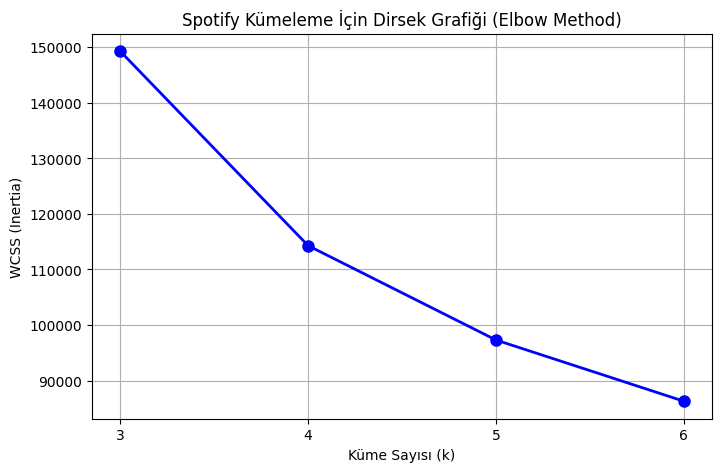

   📊 Seçilen En İyi k=4 (Silhouette=0.3269)
✅ Spotify modeli ve ölçekleyicisi başarıyla kaydedildi.

🎉 Kümeleme bölümü tamamlandı, metrics.json ara kaydedildi.


In [23]:
try:
    print("🎵 Spotify Şarkı Kümeleme Modeli Eğitiliyor...")
    spot_path = kagglehub.dataset_download("yashdev01/spotify-tracks-dataset")

    csv_files = [f for f in os.listdir(spot_path) if f.endswith('.csv')]
    if len(csv_files) == 0:
        for root, dirs, files in os.walk(spot_path):
            for file in files:
                if file.endswith('.csv'):
                    csv_files.append(os.path.join(root, file))
        csv_file_path = csv_files[0]
    else:
        csv_file_path = os.path.join(spot_path, csv_files[0])

    spot_df = pd.read_csv(csv_file_path)
    explore_dataset(spot_df, "Spotify Tracks")

    features_spot = ['danceability', 'energy', 'loudness']
    X_spot = spot_df[features_spot].dropna()

    scaler_spot = StandardScaler()
    X_spot_scaled = scaler_spot.fit_transform(X_spot)

    # --- DİRSEK YÖNTEMİ (ELBOW METHOD) BÖLÜMÜ ---
    k_values = [3, 4, 5, 6]
    wcss = []
    silhouette_scores = {}
    models = {}

    for k in k_values:
        km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_spot_scaled)
        wcss.append(km.inertia_)  # WCSS (Inertia) değerini listeye ekle
        models[k] = km

        # Silhouette skorunu da hesaplamaya devam ediyoruz
        score = silhouette_score(X_spot_scaled, km.labels_)
        silhouette_scores[k] = score
        print(f"   k={k}: WCSS (Inertia)={km.inertia_:.2f}, Silhouette={score:.4f}")

    # Dirsek Grafiğini Çizme ve Kaydetme
    plt.figure(figsize=(8, 5))
    plt.plot(k_values, wcss, 'bo-', linewidth=2, markersize=8)
    plt.title('Spotify Kümeleme İçin Dirsek Grafiği (Elbow Method)')
    plt.xlabel('Küme Sayısı (k)')
    plt.ylabel('WCSS (Inertia)')
    plt.xticks(k_values)
    plt.grid(True)
    plt.savefig('spotify_elbow_chart.png')  # Grafiği çalışma dizinine kaydeder
    plt.show()

    # --- EN İYİ K SEÇİMİ ---
    # WCSS grafiğini görsel olarak inceleyip manuel k seçmek en doğrusudur.
    # Ancak kodun otomatik akması için yine en yüksek Silhouette skoruna sahip k'yi seçiyoruz:
    best_k = max(silhouette_scores, key=silhouette_scores.get)
    kmeans_spot = models[best_k]

    joblib.dump(kmeans_spot, 'models/spotify_model.pkl')
    joblib.dump(scaler_spot, 'models/spotify_scaler.pkl')

    add_clustering_metrics("spotify", X_spot_scaled, kmeans_spot.labels_, n_clusters=best_k)
    print(f"   📊 Seçilen En İyi k={best_k} (Silhouette={metrics['spotify']['Silhouette']:.4f})")
    print("✅ Spotify modeli ve ölçekleyicisi başarıyla kaydedildi.\n")
except Exception as e:
    add_error_metric("spotify", e)

save_metrics()
print("🎉 Kümeleme bölümü tamamlandı, metrics.json ara kaydedildi.")

## ***4-Görüntü Sınıflandırma***

### *Maske Kullanımı Tespiti*

> **📌 Amaç:** Yüz görüntüsünden maske takılı olup olmadığını sınıflandırmak.  
> **📂 Veri Seti:** `face-mask-dataset`  
> **🧠 Model:** RandomForestClassifier (64×64 piksel düzleştirilmiş)  
> **📊 Değerlendirme:** Accuracy, F1

In [24]:
import cv2

try:
    print("😷 Maske Tespit Modeli Eğitiliyor...")
    mask_path = kagglehub.dataset_download("omkargurav/face-mask-dataset")

    data_mask, labels_mask = [], []
    for label, folder in enumerate(['with_mask', 'without_mask']):
        folder_path = os.path.join(mask_path, 'data', folder)
        if not os.path.exists(folder_path):
            continue
        for img_name in os.listdir(folder_path)[:200]:
            try:
                img = cv2.imread(os.path.join(folder_path, img_name))
                img = cv2.resize(img, (64, 64))
                data_mask.append(img.flatten())
                labels_mask.append(label)
            except Exception:
                continue

    X_mask = np.array(data_mask)
    y_mask = np.array(labels_mask)
    explore_array(X_mask, y_mask, "Maske Tespiti", class_names=["Maskeli", "Maskesiz"])

    X_tr_mk, X_te_mk, y_tr_mk, y_te_mk = train_test_split(X_mask, y_mask, test_size=0.2, random_state=42)

    param_grid_mask = {'n_estimators': [50, 100], 'max_depth': [None, 10, 20]}
    search_mask = RandomizedSearchCV(RandomForestClassifier(random_state=42), param_grid_mask,
                                      n_iter=4, cv=3, random_state=42, n_jobs=-1)
    search_mask.fit(X_tr_mk, y_tr_mk)
    mask_model = search_mask.best_estimator_
    joblib.dump(mask_model, 'models/mask_model.pkl')

    y_pred_mask = mask_model.predict(X_te_mk)
    add_classification_metrics("mask", y_te_mk, y_pred_mask)
    metrics["mask"]["CV_Accuracy"] = round(float(search_mask.best_score_), 4)
    print(f"   📊 Accuracy={metrics['mask']['Accuracy']}  F1={metrics['mask']['F1']}")
    print(f"   🔧 En iyi parametreler: {search_mask.best_params_}  (3-fold CV Accuracy={metrics['mask']['CV_Accuracy']})")
    show_classification_report("Maske Tespiti", y_te_mk, y_pred_mask, target_names=["Maskeli", "Maskesiz"])
    print("✅ Maske tespit modeli kaydedildi: models/mask_model.pkl\n")
except Exception as e:
    add_error_metric("mask", e)

save_metrics()
print("🎉 Görüntü sınıflandırma bölümü tamamlandı, metrics.json ara kaydedildi.")

😷 Maske Tespit Modeli Eğitiliyor...
Using Colab cache for faster access to the 'face-mask-dataset' dataset.

📊 VERİ SETİ İNCELEMESİ VE TEMİZLİĞİ (görüntü/dizi): Maske Tespiti

🔹 X şekli (shape): (400, 12288)
🔹 y şekli (shape): (400,)
   ✅ Eksik değer yok.

🔹 Sınıf dağılımı:
   Maskeli: 200 örnek
   Maskesiz: 200 örnek

   📊 Accuracy=0.825  F1=0.8244
   🔧 En iyi parametreler: {'n_estimators': 100, 'max_depth': None}  (3-fold CV Accuracy=0.8187)

🔎 Maske Tespiti — Confusion Matrix:
[[38  6]
 [ 8 28]]

🔎 Maske Tespiti — Classification Report:
              precision    recall  f1-score   support

     Maskeli       0.83      0.86      0.84        44
    Maskesiz       0.82      0.78      0.80        36

    accuracy                           0.82        80
   macro avg       0.82      0.82      0.82        80
weighted avg       0.82      0.82      0.82        80

✅ Maske tespit modeli kaydedildi: models/mask_model.pkl

🎉 Görüntü sınıflandırma bölümü tamamlandı, metrics.json ara kaydedildi

## ***5-NLP Modelleri***

### *SMS Spam / Kimlik Avı Tespiti*

> **📌 Amaç:** SMS metninin spam mı yoksa normal (ham) mı olduğunu tespit etmek.  
> **📂 Veri Seti:** `sms-spam-collection`  
> **🧠 Model:** MultinomialNB + TF-IDF  
> **📊 Değerlendirme:** Accuracy, F1

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

try:
    print("📧 SMS Spam Tespit Modeli Eğitiliyor...")
    spam_path = kagglehub.dataset_download("uciml/sms-spam-collection-dataset")
    spam_df = pd.read_csv(os.path.join(spam_path, "spam.csv"), encoding='latin-1')

    spam_df = spam_df[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'text'})
    explore_dataset(spam_df, "SMS Spam Collection (v1/v2 seçilmiş)")

    spam_df['label'] = spam_df['label'].map({'ham': 0, 'spam': 1})

    tfidf_spam = TfidfVectorizer(stop_words='english', max_features=3000)
    X_spam = tfidf_spam.fit_transform(spam_df['text'])
    y_spam = spam_df['label']


    X_tr_sp, X_te_sp, y_tr_sp, y_te_sp = train_test_split(X_spam, y_spam, test_size=0.2, random_state=42)
    spam_model = MultinomialNB()
    spam_model.fit(X_tr_sp, y_tr_sp)

    joblib.dump(spam_model, 'models/spam_model.pkl')
    joblib.dump(tfidf_spam, 'models/spam_vectorizer.pkl')

    y_pred_spam = spam_model.predict(X_te_sp)
    add_classification_metrics("sms", y_te_sp, y_pred_spam)
    print(f"   📊 Accuracy={metrics['sms']['Accuracy']}  F1={metrics['sms']['F1']}")
    show_classification_report("SMS Spam", y_te_sp, y_pred_spam, target_names=["Ham (Normal)", "Spam"])
    print("✅ SMS Spam modeli ve vektörleştiricisi kaydedildi.\n")
except Exception as e:
    add_error_metric("sms", e)

📧 SMS Spam Tespit Modeli Eğitiliyor...
Using Colab cache for faster access to the 'sms-spam-collection-dataset' dataset.

📊 VERİ SETİ İNCELEMESİ VE TEMİZLİĞİ: SMS Spam Collection (v1/v2 seçilmiş)

🔹 Shape (satır, sütun): (5572, 2)

🔹 İlk 5 satır:


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."



🔹 info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   5572 non-null   object
 1   text    5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB

🔹 Eksik değerler (isnull().sum()):
   ✅ Eksik değer yok.

🔹 describe() (sayısal sütunlar):


,label,text
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30



   📊 Accuracy=0.9803  F1=0.9796

🔎 SMS Spam — Confusion Matrix:
[[965   0]
 [ 22 128]]

🔎 SMS Spam — Classification Report:
              precision    recall  f1-score   support

Ham (Normal)       0.98      1.00      0.99       965
        Spam       1.00      0.85      0.92       150

    accuracy                           0.98      1115
   macro avg       0.99      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115

✅ SMS Spam modeli ve vektörleştiricisi kaydedildi.



### *IMDb Film Yorumları Duygu Analizi*

> **📌 Amaç:** Film yorumunun pozitif mi negatif mi olduğunu analiz etmek.  
> **📂 Veri Seti:** `imdb-50k-reviews`  
> **🧠 Model:** LogisticRegression + TF-IDF  
> **📊 Değerlendirme:** Accuracy, F1

In [26]:
try:
    print("🍿 IMDb Duygu Analizi Modeli Eğitiliyor...")
    imdb_path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
    imdb_df = pd.read_csv(os.path.join(imdb_path, "IMDB Dataset.csv"))

    eksik_sutunlar_imdb = imdb_df.columns[imdb_df.isnull().any()].tolist()
    if eksik_sutunlar_imdb:
        print(f"🔧 Eksik değer içeren sütunlar çıkarılıyor: {eksik_sutunlar_imdb}")
        imdb_df = imdb_df.drop(columns=eksik_sutunlar_imdb)

    explore_dataset(imdb_df, "IMDb 50K Film Yorumu")
    imdb_df['sentiment'] = imdb_df['sentiment'].map({'negative': 0, 'positive': 1})

    imdb_sub = imdb_df.sample(10000, random_state=42)
    tfidf_imdb = TfidfVectorizer(stop_words='english', max_features=5000)
    X_imdb = tfidf_imdb.fit_transform(imdb_sub['review'])
    y_imdb = imdb_sub['sentiment']

    X_tr_i, X_te_i, y_tr_i, y_te_i = train_test_split(X_imdb, y_imdb, test_size=0.2, random_state=42)
    imdb_model = LogisticRegression(max_iter=200)
    imdb_model.fit(X_tr_i, y_tr_i)

    joblib.dump(imdb_model, 'models/imdb_model.pkl')
    joblib.dump(tfidf_imdb, 'models/imdb_vectorizer.pkl')

    y_pred_imdb = imdb_model.predict(X_te_i)
    add_classification_metrics("imdb_sentiment", y_te_i, y_pred_imdb)
    print(f"   📊 Accuracy={metrics['imdb_sentiment']['Accuracy']}  F1={metrics['imdb_sentiment']['F1']}")
    show_classification_report("IMDb Duygu Analizi", y_te_i, y_pred_imdb, target_names=["Negatif", "Pozitif"])
    print("✅ IMDb duygu analizi modeli ve vektörleştiricisi kaydedildi.\n")
except Exception as e:
    add_error_metric("imdb_sentiment", e)

🍿 IMDb Duygu Analizi Modeli Eğitiliyor...
Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.

📊 VERİ SETİ İNCELEMESİ VE TEMİZLİĞİ: IMDb 50K Film Yorumu

🔹 Shape (satır, sütun): (50000, 2)

🔹 İlk 5 satır:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive



🔹 info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB

🔹 Eksik değerler (isnull().sum()):
   ✅ Eksik değer yok.

🔹 describe() (sayısal sütunlar):


,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000



   📊 Accuracy=0.873  F1=0.8729

🔎 IMDb Duygu Analizi — Confusion Matrix:
[[845 154]
 [100 901]]

🔎 IMDb Duygu Analizi — Classification Report:
              precision    recall  f1-score   support

     Negatif       0.89      0.85      0.87       999
     Pozitif       0.85      0.90      0.88      1001

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000

✅ IMDb duygu analizi modeli ve vektörleştiricisi kaydedildi.



### *Sahte Haber Tespiti*

> **📌 Amaç:** Haber metninin gerçek mi sahte mi olduğunu tespit etmek.  
> **📂 Veri Seti:** `fake-and-real-news`  
> **🧠 Model:** LogisticRegression + TF-IDF  
> **📊 Değerlendirme:** Accuracy, F1

In [27]:
try:
    print("📰 Sahte Haber Tespit Modeli Eğitiliyor...")
    news_path = kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset")

    fake_df = pd.read_csv(os.path.join(news_path, "Fake.csv"))
    real_df = pd.read_csv(os.path.join(news_path, "True.csv"))
    fake_df['label'] = 1
    real_df['label'] = 0
    explore_dataset(fake_df, "Sahte Haberler (Fake.csv)")
    explore_dataset(real_df, "Gerçek Haberler (True.csv)")

    news_df = pd.concat([
        fake_df.sample(4000, random_state=42), real_df.sample(4000, random_state=42)
    ]).reset_index(drop=True)

    tfidf_news = TfidfVectorizer(stop_words='english', max_features=5000)
    X_news = tfidf_news.fit_transform(news_df['text'])
    y_news = news_df['label']

    X_tr_n, X_te_n, y_tr_n, y_te_n = train_test_split(X_news, y_news, test_size=0.2, random_state=42)
    news_model = LogisticRegression()
    news_model.fit(X_tr_n, y_tr_n)

    joblib.dump(news_model, 'models/news_model.pkl')
    joblib.dump(tfidf_news, 'models/news_vectorizer.pkl')

    y_pred_news = news_model.predict(X_te_n)
    add_classification_metrics("fake_news", y_te_n, y_pred_news)
    print(f"   📊 Accuracy={metrics['fake_news']['Accuracy']}  F1={metrics['fake_news']['F1']}")
    show_classification_report("Sahte Haber Tespiti", y_te_n, y_pred_news, target_names=["Gerçek", "Sahte"])
    print("✅ Sahte Haber modeli ve vektörleştiricisi kaydedildi.\n")
except Exception as e:
    add_error_metric("fake_news", e)

save_metrics()
print("🎉 NLP bölümü tamamlandı, metrics.json ara kaydedildi.")

📰 Sahte Haber Tespit Modeli Eğitiliyor...
Using Colab cache for faster access to the 'fake-and-real-news-dataset' dataset.

📊 VERİ SETİ İNCELEMESİ VE TEMİZLİĞİ: Sahte Haberler (Fake.csv)

🔹 Shape (satır, sütun): (23481, 5)

🔹 İlk 5 satır:


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",1



🔹 info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
 4   label    23481 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 917.4+ KB

🔹 Eksik değerler (isnull().sum()):
   ✅ Eksik değer yok.

🔹 describe() (sayısal sütunlar):


,label
count,23481.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0




📊 VERİ SETİ İNCELEMESİ VE TEMİZLİĞİ: Gerçek Haberler (True.csv)

🔹 Shape (satır, sütun): (21417, 5)

🔹 İlk 5 satır:


,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",0
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",0
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",0
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",0
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",0



🔹 info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
 4   label    21417 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 836.7+ KB

🔹 Eksik değerler (isnull().sum()):
   ✅ Eksik değer yok.

🔹 describe() (sayısal sütunlar):


,label
count,21417.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0



   📊 Accuracy=0.9756  F1=0.9756

🔎 Sahte Haber Tespiti — Confusion Matrix:
[[785  11]
 [ 28 776]]

🔎 Sahte Haber Tespiti — Classification Report:
              precision    recall  f1-score   support

      Gerçek       0.97      0.99      0.98       796
       Sahte       0.99      0.97      0.98       804

    accuracy                           0.98      1600
   macro avg       0.98      0.98      0.98      1600
weighted avg       0.98      0.98      0.98      1600

✅ Sahte Haber modeli ve vektörleştiricisi kaydedildi.

🎉 NLP bölümü tamamlandı, metrics.json ara kaydedildi.


## ***6-Öneri Sistemleri***

### *IMDb Film Öneri Sistemi*

> **📌 Amaç:** İçerik tabanlı film önerisi (özet + tür benzerliği).  
> **📂 Veri Seti:** `tmdb-5000-movies`  
> **🧠 Model:** TF-IDF + Cosine Similarity  
> **📊 Değerlendirme:** Metrik yok (unsupervised)

In [28]:
from sklearn.metrics.pairwise import cosine_similarity

try:
    print("🍿 Film Öneri Sistemi Hazırlanıyor...")
    movie_path = kagglehub.dataset_download("tmdb/tmdb-movie-metadata")
    movies = pd.read_csv(os.path.join(movie_path, "tmdb_5000_movies.csv"))
    explore_dataset(movies, "TMDB 5000 Film Metadata")

    movies['overview'] = movies['overview'].fillna('')
    movies['genres'] = movies['genres'].fillna('')
    movies['features'] = movies['overview'] + " " + movies['genres']

    movies_sub = movies.sort_values('popularity', ascending=False).head(1500).reset_index(drop=True)

    tfidf = TfidfVectorizer(stop_words='english')
    tfidf_matrix = tfidf.fit_transform(movies_sub['features'])
    movie_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

    joblib.dump(movies_sub[['title']], 'models/movie_data.pkl')
    joblib.dump(movie_sim, 'models/movie_similarity.pkl')

    add_none_metric("movie_rec", "İçerik tabanlı (unsupervised) öneri sistemi — accuracy/R² gibi tek bir "
                                  "başarı metriği yoktur.")
    print("✅ Film öneri verileri kaydedildi.\n")
except Exception as e:
    add_error_metric("movie_rec", e)

🍿 Film Öneri Sistemi Hazırlanıyor...


100%|██████████| 8.89M/8.89M [00:00<00:00, 72.2MB/s]

Extracting files...



📊 VERİ SETİ İNCELEMESİ VE TEMİZLİĞİ: TMDB 5000 Film Metadata

🔹 Shape (satır, sütun): (4803, 20)

🔹 İlk 5 satır:


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124



🔹 info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status    

,Eksik Değer Sayısı
homepage,3091
overview,3
release_date,1
runtime,2
tagline,844



⚠️ Eksik satırlar yerinde (inplace) temizleniyor...
   ✅ Toplam 3310 adet eksik satır silindi.
   🔹 Yeni Shape (satır, sütun): (1493, 20)

🔹 describe() (sayısal sütunlar):


,budget,id,popularity,revenue,runtime,vote_average,vote_count
count,1.493000e+03,1493.000000,1493.000000,1.493000e+03,1493.000000,1493.000000,1493.000000
mean,4.589534e+07,65498.552579,35.749280,1.550083e+08,108.657736,6.272873,1323.557267
std,5.369219e+07,89841.824027,48.207525,2.408712e+08,19.378758,0.970480,1792.459010
min,0.000000e+00,11.000000,0.023681,0.000000e+00,0.000000,0.000000,0.000000
25%,7.500000e+06,8090.000000,11.624230,9.455232e+06,95.000000,5.800000,207.000000
50%,2.700000e+07,26320.000000,25.281197,6.254895e+07,106.000000,6.300000,616.000000
75%,6.300000e+07,76341.000000,45.149948,1.860537e+08,120.000000,6.900000,1652.000000
max,3.800000e+08,426469.000000,875.581305,2.787965e+09,201.000000,8.400000,13752.000000



✅ Film öneri verileri kaydedildi.



### *Kitap Tavsiye Motoru*

> **📌 Amaç:** Başlık + yazar benzerliğine dayalı kitap önerisi.  
> **📂 Veri Seti:** `goodreadsbooks`  
> **🧠 Model:** TF-IDF + Cosine Similarity  
> **📊 Değerlendirme:** Metrik yok (unsupervised)

In [29]:
try:
    print("📚 Kitap Öneri Sistemi Hazırlanıyor...")
    book_path = kagglehub.dataset_download("jealousleopard/goodreadsbooks")
    books = pd.read_csv(os.path.join(book_path, "books.csv"), on_bad_lines='skip')
    explore_dataset(books, "Goodreads Kitaplar")

    books['features'] = books['title'].fillna('') + " " + books['authors'].fillna('')
    books_sub = books.head(1500).reset_index(drop=True)

    tfidf_book = TfidfVectorizer(stop_words='english')
    tfidf_book_matrix = tfidf_book.fit_transform(books_sub['features'])
    book_sim = cosine_similarity(tfidf_book_matrix, tfidf_book_matrix)

    joblib.dump(books_sub[['title', 'authors']], 'models/book_data.pkl')
    joblib.dump(book_sim, 'models/book_similarity.pkl')

    add_none_metric("book_rec", "İçerik tabanlı (unsupervised) öneri sistemi — tek bir başarı metriği yoktur.")
    print("✅ Kitap öneri verileri başarıyla kaydedildi.\n")
except Exception as e:
    add_error_metric("book_rec", e)

📚 Kitap Öneri Sistemi Hazırlanıyor...


100%|██████████| 622k/622k [00:00<00:00, 105MB/s]

Extracting files...

📊 VERİ SETİ İNCELEMESİ VE TEMİZLİĞİ: Goodreads Kitaplar

🔹 Shape (satır, sütun): (11123, 12)

🔹 İlk 5 satır:


,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,0439785960,9780439785969,eng,652,2095690,27591,9/16/2006,Scholastic Inc.
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,0439358078,9780439358071,eng,870,2153167,29221,9/1/2004,Scholastic Inc.
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,0439554896,9780439554893,eng,352,6333,244,11/1/2003,Scholastic
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,043965548X,9780439655484,eng,435,2339585,36325,5/1/2004,Scholastic Inc.
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,0439682584,9780439682589,eng,2690,41428,164,9/13/2004,Scholastic



🔹 info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11123 entries, 0 to 11122
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   bookID              11123 non-null  int64  
 1   title               11123 non-null  object 
 2   authors             11123 non-null  object 
 3   average_rating      11123 non-null  float64
 4   isbn                11123 non-null  object 
 5   isbn13              11123 non-null  int64  
 6   language_code       11123 non-null  object 
 7     num_pages         11123 non-null  int64  
 8   ratings_count       11123 non-null  int64  
 9   text_reviews_count  11123 non-null  int64  
 10  publication_date    11123 non-null  object 
 11  publisher           11123 non-null  object 
dtypes: float64(1), int64(5), object(6)
memory usage: 1.0+ MB

🔹 Eksik değerler (isnull().sum()):
   ✅ Eksik değer yok.

🔹 describe() (sayısal sütunlar):


,bookID,average_rating,isbn13,num_pages,ratings_count,text_reviews_count
count,11123.000000,11123.000000,1.112300e+04,11123.000000,1.112300e+04,11123.000000
mean,21310.856963,3.934075,9.759880e+12,336.405556,1.794285e+04,542.048099
std,13094.727252,0.350485,4.429758e+11,241.152626,1.124992e+05,2576.619589
min,1.000000,0.000000,8.987060e+09,0.000000,0.000000e+00,0.000000
25%,10277.500000,3.770000,9.780345e+12,192.000000,1.040000e+02,9.000000
50%,20287.000000,3.960000,9.780582e+12,299.000000,7.450000e+02,47.000000
75%,32104.500000,4.140000,9.780872e+12,416.000000,5.000500e+03,238.000000
max,45641.000000,5.000000,9.790008e+12,6576.000000,4.597666e+06,94265.000000



✅ Kitap öneri verileri başarıyla kaydedildi.



### *Şarkı / Müzik Öneri Sistemi*

> **📌 Amaç:** Şarkı adı + sanatçı + tür benzerliğine dayalı müzik önerisi.  
> **📂 Veri Seti:** `spotify-tracks-dataset`  
> **🧠 Model:** TF-IDF + Cosine Similarity  
> **📊 Değerlendirme:** Metrik yok (unsupervised)

In [30]:
try:
    print("🎵 Şarkı Öneri Sistemi Hazırlanıyor...")
    song_path = kagglehub.dataset_download("yashdev01/spotify-tracks-dataset")

    csv_files = [f for f in os.listdir(song_path) if f.endswith('.csv')]
    if len(csv_files) == 0:
        for root, dirs, files in os.walk(song_path):
            for file in files:
                if file.endswith('.csv'):
                    csv_file_path = os.path.join(root, file)
                    break
    else:
        csv_file_path = os.path.join(song_path, csv_files[0])

    songs = pd.read_csv(csv_file_path)
    explore_dataset(songs, "Spotify Tracks (Öneri için)")
    songs['features'] = (songs['track_name'].fillna('') + " " +
                          songs['artists'].fillna('') + " " + songs['track_genre'].fillna(''))
    songs_clean = songs.drop_duplicates(subset=['track_name']).head(1500).reset_index(drop=True)

    tfidf_song = TfidfVectorizer(stop_words='english')
    tfidf_song_matrix = tfidf_song.fit_transform(songs_clean['features'])
    song_sim = cosine_similarity(tfidf_song_matrix, tfidf_song_matrix)

    joblib.dump(songs_clean[['track_name', 'artists']], 'models/song_data.pkl')
    joblib.dump(song_sim, 'models/song_similarity.pkl')

    add_none_metric("song_rec", "İçerik tabanlı (unsupervised) öneri sistemi — tek bir başarı metriği yoktur.")
    print("✅ Şarkı öneri verileri başarıyla kaydedildi.\n")
except Exception as e:
    add_error_metric("song_rec", e)

save_metrics()
print("🎉 Öneri sistemleri bölümü tamamlandı, metrics.json ara kaydedildi.")

🎵 Şarkı Öneri Sistemi Hazırlanıyor...
Using Colab cache for faster access to the 'spotify-tracks-dataset' dataset.

📊 VERİ SETİ İNCELEMESİ VE TEMİZLİĞİ: Spotify Tracks (Öneri için)

🔹 Shape (satır, sütun): (114000, 22)

🔹 İlk 5 satır:


,Unnamed: 0.1,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic



🔹 info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0.1      114000 non-null  int64  
 1   Unnamed: 0        114000 non-null  int64  
 2   track_id          114000 non-null  object 
 3   artists           113999 non-null  object 
 4   album_name        113999 non-null  object 
 5   track_name        113999 non-null  object 
 6   popularity        114000 non-null  int64  
 7   duration_ms       114000 non-null  int64  
 8   explicit          114000 non-null  bool   
 9   danceability      114000 non-null  float64
 10  energy            114000 non-null  float64
 11  key               114000 non-null  int64  
 12  loudness          114000 non-null  float64
 13  mode              114000 non-null  int64  
 14  speechiness       114000 non-null  float64
 15  acousticness      114000 non-null  float64
 16  instrumen

,Eksik Değer Sayısı
artists,1
album_name,1
track_name,1



⚠️ Eksik satırlar yerinde (inplace) temizleniyor...
   ✅ Toplam 1 adet eksik satır silindi.
   🔹 Yeni Shape (satır, sütun): (113999, 22)

🔹 describe() (sayısal sütunlar):


,Unnamed: 0.1,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,113999.000000,113999.000000,113999.000000,1.139990e+05,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000
mean,56999.421925,56999.421925,33.238827,2.280312e+05,0.566801,0.641383,5.309126,-8.258950,0.637558,0.084652,0.314907,0.156051,0.213554,0.474066,122.147695,3.904034
std,32909.243463,32909.243463,22.304959,1.072961e+05,0.173543,0.251530,3.559999,5.029357,0.480708,0.105733,0.332522,0.309556,0.190378,0.259261,29.978290,0.432623
min,0.000000,0.000000,0.000000,8.586000e+03,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.500000,28499.500000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218500,4.000000
50%,56999.000000,56999.000000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.500000,85499.500000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.597500,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000



✅ Şarkı öneri verileri başarıyla kaydedildi.

🎉 Öneri sistemleri bölümü tamamlandı, metrics.json ara kaydedildi.


##  ***7-Zaman Serisi Modelleri***

### *Hisse Senedi Fiyat Tahmini (yfinance)*

> **📌 Amaç:** AAPL kapanış fiyatını bir önceki günün fiyatından (lag-1) tahmin etmek.  
> **📂 Veri Seti:** `yfinance` (son 5 yıl)  
> **🧠 Model:** LinearRegression — **naif persistence modeli**  
> **📊 Değerlendirme:** R², RMSE, MAE

In [31]:
from sklearn.linear_model import LinearRegression

try:
    print("📈 Hisse Senedi Tahmin Modeli Eğitiliyor (yfinance)...")
    import yfinance as yf

    ticker = yf.Ticker("AAPL")
    stock_df = ticker.history(period="5y")
    stock_df.columns = [col.lower() for col in stock_df.columns]
    explore_dataset(stock_df, "AAPL Hisse Senedi (5 Yıl)")

    stock_df['close_lag1'] = stock_df['close'].shift(1)
    stock_df = stock_df.dropna()

    X_stock = stock_df[['close_lag1']]
    y_stock = stock_df['close']

    split_idx = int(len(X_stock) * 0.8)
    X_tr_st, X_te_st = X_stock.iloc[:split_idx], X_stock.iloc[split_idx:]
    y_tr_st, y_te_st = y_stock.iloc[:split_idx], y_stock.iloc[split_idx:]

    eval_stock_model = LinearRegression().fit(X_tr_st, y_tr_st)
    y_pred_stock = eval_stock_model.predict(X_te_st)
    add_regression_metrics("stock", y_te_st, y_pred_stock, unit="$")
    print(f"   📊 R²={metrics['stock']['R2']}  RMSE={metrics['stock']['RMSE']}  MAE={metrics['stock']['MAE']}")

    # Üretim modeli (Streamlit'te kullanılacak) TÜM veriyle nihai olarak eğitilir
    stock_model = LinearRegression()
    stock_model.fit(X_stock, y_stock)
    joblib.dump(stock_model, 'models/stock_model.pkl')
    joblib.dump(stock_df['close'].tail(30).values, 'models/stock_recent.pkl')
    print("✅ Hisse senedi modeli kaydedildi.\n")
except Exception as e:
    add_error_metric("stock", e)

📈 Hisse Senedi Tahmin Modeli Eğitiliyor (yfinance)...

📊 VERİ SETİ İNCELEMESİ VE TEMİZLİĞİ: AAPL Hisse Senedi (5 Yıl)

🔹 Shape (satır, sütun): (1254, 7)

🔹 İlk 5 satır:


,open,high,low,close,volume,dividends,stock splits
Date,,,,,,,
2021-07-23 00:00:00-04:00,143.824649,144.965107,143.210551,144.809143,71447400,0.0,0.0
2021-07-26 00:00:00-04:00,144.526479,146.047090,143.970864,145.228302,72434100,0.0,0.0
2021-07-27 00:00:00-04:00,145.354989,145.442728,141.875133,143.064331,104818600,0.0,0.0
2021-07-28 00:00:00-04:00,141.153813,143.259281,138.941122,141.319519,118931200,0.0,0.0
2021-07-29 00:00:00-04:00,141.036879,142.849919,140.929656,141.962891,56699500,0.0,0.0



🔹 info():
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1254 entries, 2021-07-23 00:00:00-04:00 to 2026-07-22 00:00:00-04:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   open          1254 non-null   float64
 1   high          1254 non-null   float64
 2   low           1254 non-null   float64
 3   close         1254 non-null   float64
 4   volume        1254 non-null   int64  
 5   dividends     1254 non-null   float64
 6   stock splits  1254 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 78.4 KB

🔹 Eksik değerler (isnull().sum()):
   ✅ Eksik değer yok.

🔹 describe() (sayısal sütunlar):


,open,high,low,close,volume,dividends,stock splits
count,1254.000000,1254.000000,1254.000000,1254.000000,1.254000e+03,1254.000000,1254.0
mean,195.638775,197.799023,193.708363,195.843897,6.477341e+07,0.003868,0.0
std,46.354099,46.788425,45.984711,46.407022,2.855508e+07,0.030449,0.0
min,123.907026,125.637653,122.097746,122.933548,1.791060e+07,0.000000,0.0
25%,158.064999,160.224726,156.089529,158.329124,4.556162e+07,0.000000,0.0
50%,184.197682,185.644258,182.217411,184.364166,5.671245e+07,0.000000,0.0
75%,227.767579,230.186282,225.809780,228.018211,7.645238e+07,0.000000,0.0
max,333.510010,334.989990,329.000000,333.739990,3.186799e+08,0.270000,0.0



   📊 R²=0.975  RMSE=4.1682  MAE=2.959
✅ Hisse senedi modeli kaydedildi.



### *Hava Durumu / Sıcaklık Tahmini*

> **📌 Amaç:** Delhi günlük ortalama sıcaklığını lag-1 ile tahmin etmek.  
> **📂 Veri Seti:** `daily-climate-time-series`  
> **🧠 Model:** LinearRegression (lag-1)  
> **📊 Değerlendirme:** R², RMSE, MAE

In [32]:
try:
    print("🌦️ Hava Durumu Tahmin Modeli Eğitiliyor...")
    weather_path = kagglehub.dataset_download("sumanthvrao/daily-climate-time-series-data")
    weather_df = pd.read_csv(os.path.join(weather_path, "DailyDelhiClimateTrain.csv"))
    explore_dataset(weather_df, "Delhi Günlük İklim Verisi")

    weather_df['meantemp_Lag1'] = weather_df['meantemp'].shift(1)
    weather_df = weather_df.dropna()

    X_weather = weather_df[['meantemp_Lag1']]
    y_weather = weather_df['meantemp']

    split_idx_w = int(len(X_weather) * 0.8)
    X_tr_w2, X_te_w2 = X_weather.iloc[:split_idx_w], X_weather.iloc[split_idx_w:]
    y_tr_w2, y_te_w2 = y_weather.iloc[:split_idx_w], y_weather.iloc[split_idx_w:]

    eval_weather_model = LinearRegression().fit(X_tr_w2, y_tr_w2)
    y_pred_weather = eval_weather_model.predict(X_te_w2)
    add_regression_metrics("weather", y_te_w2, y_pred_weather, unit="°C")
    print(f"   📊 R²={metrics['weather']['R2']}  RMSE={metrics['weather']['RMSE']}  MAE={metrics['weather']['MAE']}")

    weather_model = LinearRegression()
    weather_model.fit(X_weather, y_weather)
    joblib.dump(weather_model, 'models/weather_model.pkl')
    joblib.dump(weather_df['meantemp'].tail(30).values, 'models/weather_recent.pkl')
    print("✅ Hava durumu modeli kaydedildi.\n")
except Exception as e:
    add_error_metric("weather", e)

🌦️ Hava Durumu Tahmin Modeli Eğitiliyor...
Using Colab cache for faster access to the 'daily-climate-time-series-data' dataset.

📊 VERİ SETİ İNCELEMESİ VE TEMİZLİĞİ: Delhi Günlük İklim Verisi

🔹 Shape (satır, sütun): (1462, 5)

🔹 İlk 5 satır:


,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000



🔹 info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1462 non-null   object 
 1   meantemp      1462 non-null   float64
 2   humidity      1462 non-null   float64
 3   wind_speed    1462 non-null   float64
 4   meanpressure  1462 non-null   float64
dtypes: float64(4), object(1)
memory usage: 57.2+ KB

🔹 Eksik değerler (isnull().sum()):
   ✅ Eksik değer yok.

🔹 describe() (sayısal sütunlar):


,meantemp,humidity,wind_speed,meanpressure
count,1462.000000,1462.000000,1462.000000,1462.000000
mean,25.495521,60.771702,6.802209,1011.104548
std,7.348103,16.769652,4.561602,180.231668
min,6.000000,13.428571,0.000000,-3.041667
25%,18.857143,50.375000,3.475000,1001.580357
50%,27.714286,62.625000,6.221667,1008.563492
75%,31.305804,72.218750,9.238235,1014.944901
max,38.714286,100.000000,42.220000,7679.333333



   📊 R²=0.912  RMSE=1.6784  MAE=1.2744
✅ Hava durumu modeli kaydedildi.



### *Mağaza Satış Tahmini (Walmart — Sentetik Zaman Serisi)*

> **📌 Amaç:** Haftalık mağaza satışını lag-1 ile tahmin etmek.  
> **📂 Veri Seti:** **SENTETİK** (rastgele üretilmiş veri)  
> **🧠 Model:** LinearRegression (lag-1)  
> **📊 Değerlendirme:** R², RMSE, MAE

In [33]:
# NOT: Gerçek Walmart veri seti Kaggle'da mevcut olmadığı için sentetik veri kullanılmaktadır.
# Gerçek veri için: https://www.kaggle.com/datasets/mikhail1681/walmart-sales
try:
    print("🛒 Mağaza Satış Tahmin Modeli Eğitiliyor...")
    np.random.seed(42)
    dates = pd.date_range(start="2010-02-05", periods=143, freq="W")
    weekly_sales = 1500000 + np.sin(np.linspace(0, 20, 143)) * 300000 + np.random.normal(0, 50000, 143)

    walmart_sub = pd.DataFrame({'Date': dates, 'Weekly_Sales': weekly_sales}).sort_values('Date').reset_index(drop=True)
    explore_dataset(walmart_sub, "Mağaza Haftalık Satış (sentetik)")
    walmart_sub['Sales_Lag1'] = walmart_sub['Weekly_Sales'].shift(1)
    walmart_sub = walmart_sub.dropna()

    X_walmart = walmart_sub[['Sales_Lag1']]
    y_walmart = walmart_sub['Weekly_Sales']

    split_idx_wm = int(len(X_walmart) * 0.8)
    X_tr_wm, X_te_wm = X_walmart.iloc[:split_idx_wm], X_walmart.iloc[split_idx_wm:]
    y_tr_wm, y_te_wm = y_walmart.iloc[:split_idx_wm], y_walmart.iloc[split_idx_wm:]

    eval_walmart_model = LinearRegression().fit(X_tr_wm, y_tr_wm)
    y_pred_walmart = eval_walmart_model.predict(X_te_wm)
    add_regression_metrics("walmart", y_te_wm, y_pred_walmart, unit="$")
    print(f"   📊 R²={metrics['walmart']['R2']}  RMSE={metrics['walmart']['RMSE']}  MAE={metrics['walmart']['MAE']}")

    walmart_model = LinearRegression()
    walmart_model.fit(X_walmart, y_walmart)
    joblib.dump(walmart_model, 'models/walmart_model.pkl')
    joblib.dump(walmart_sub['Weekly_Sales'].tail(15).values, 'models/walmart_recent.pkl')
    print("✅ Mağaza satış modeli başarıyla kaydedildi.\n")
except Exception as e:
    add_error_metric("walmart", e)

save_metrics()
print("🎉 Zaman serisi bölümü tamamlandı, metrics.json ara kaydedildi.")

🛒 Mağaza Satış Tahmin Modeli Eğitiliyor...

📊 VERİ SETİ İNCELEMESİ VE TEMİZLİĞİ: Mağaza Haftalık Satış (sentetik)

🔹 Shape (satır, sütun): (143, 2)

🔹 İlk 5 satır:


,Date,Weekly_Sales
0,2010-02-07,1.524836e+06
1,2010-02-14,1.535201e+06
2,2010-02-21,1.615778e+06
3,2010-02-28,1.699174e+06
4,2010-03-07,1.648506e+06



🔹 info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143 entries, 0 to 142
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          143 non-null    datetime64[ns]
 1   Weekly_Sales  143 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 2.4 KB

🔹 Eksik değerler (isnull().sum()):
   ✅ Eksik değer yok.

🔹 describe() (sayısal sütunlar):


,Date,Weekly_Sales
count,143,1.430000e+02
mean,2011-06-19 00:00:00,1.505621e+06
min,2010-02-07 00:00:00,1.103199e+06
25%,2010-10-13 12:00:00,1.308643e+06
50%,2011-06-19 00:00:00,1.534993e+06
75%,2012-02-22 12:00:00,1.696706e+06
max,2012-10-28 00:00:00,1.844832e+06
std,NaN,2.142372e+05



   📊 R²=0.7669  RMSE=91283.4797  MAE=79987.0904
✅ Mağaza satış modeli başarıyla kaydedildi.

🎉 Zaman serisi bölümü tamamlandı, metrics.json ara kaydedildi.


## ***8-Veri Görselleştirme Setleri***

### *Küresel Sosyal Medya Kullanım İstatistikleri*

> **📌 Amaç:** Sosyal medya kullanım süresi ve platform dağılımını görselleştirmek.  
> **📂 Veri Seti:** **SENTETİK**  
> **🧠 Model:** Model yok — yalnızca görselleştirme  
> **📊 Değerlendirme:** —

In [34]:
try:
    print("📱 Sosyal Medya Verisi Hazırlanıyor...")
    np.random.seed(42)
    n_samples = 500

    platforms = ['Instagram', 'TikTok', 'X (Twitter)', 'YouTube']
    genders = ['Male', 'Female', 'Non-binary']
    emotions = ['Happy', 'Anxious', 'Sad', 'Neutral', 'Bored']

    sm_data = {
        'Age': np.random.randint(13, 65, n_samples),
        'Gender': np.random.choice(genders, n_samples),
        'Platform': np.random.choice(platforms, n_samples),
        'Daily_Usage_Time (minutes)': np.random.randint(15, 360, n_samples),
        'Dominant_Emotion': np.random.choice(emotions, n_samples)
    }

    sm_clean = pd.DataFrame(sm_data)
    explore_dataset(sm_clean, "Sosyal Medya Kullanım (sentetik)")
    sm_clean.to_csv('models/social_media_viz.csv', index=False)

    add_none_metric("social_media_viz", "Bu sekmede eğitilen bir model yok, sadece görselleştirme var.")
    print("✅ Sosyal medya verisi kaydedildi.\n")
except Exception as e:
    add_error_metric("social_media_viz", e)

📱 Sosyal Medya Verisi Hazırlanıyor...

📊 VERİ SETİ İNCELEMESİ VE TEMİZLİĞİ: Sosyal Medya Kullanım (sentetik)

🔹 Shape (satır, sütun): (500, 5)

🔹 İlk 5 satır:


,Age,Gender,Platform,Daily_Usage_Time (minutes),Dominant_Emotion
0,51,Male,Instagram,344,Happy
1,64,Non-binary,Instagram,277,Sad
2,41,Non-binary,TikTok,175,Sad
3,27,Male,X (Twitter),165,Happy
4,55,Female,YouTube,99,Happy



🔹 info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Age                         500 non-null    int64 
 1   Gender                      500 non-null    object
 2   Platform                    500 non-null    object
 3   Daily_Usage_Time (minutes)  500 non-null    int64 
 4   Dominant_Emotion            500 non-null    object
dtypes: int64(2), object(3)
memory usage: 19.7+ KB

🔹 Eksik değerler (isnull().sum()):
   ✅ Eksik değer yok.

🔹 describe() (sayısal sütunlar):


,Age,Daily_Usage_Time (minutes)
count,500.000000,500.000000
mean,39.220000,184.478000
std,15.036082,102.574307
min,13.000000,16.000000
25%,27.000000,89.750000
50%,40.000000,189.000000
75%,52.000000,275.000000
max,64.000000,359.000000



✅ Sosyal medya verisi kaydedildi.



### *Küresel Karbon Salınımı ve İklim Değişikliği*

> **📌 Amaç:** Ülke bazlı CO₂ salınımı trendlerini görselleştirmek.  
> **📂 Veri Seti:** **SENTETİK**  
> **🧠 Model:** Model yok — yalnızca görselleştirme  
> **📊 Değerlendirme:** —

In [35]:
try:
    print("⚡ Karbon Salınımı Verisi Hazırlanıyor...")
    years = list(range(1990, 2024))
    countries = ['United States', 'China', 'United Kingdom', 'Germany', 'India', 'Japan']

    co2_records = []
    for country in countries:
        base_total = np.random.randint(500, 3000)
        for year in years:
            idx = year - 1990
            if country in ['China', 'India']:
                trend = 1.0 + (idx * 0.04) + np.random.normal(0, 0.02)
            else:
                trend = 1.0 - (idx * 0.01) + np.random.normal(0, 0.02)

            total = max(100, base_total * trend)
            coal = total * 0.4 + np.random.normal(0, 10)
            oil = total * 0.35 + np.random.normal(0, 10)
            gas = total * 0.25 + np.random.normal(0, 5)

            co2_records.append({
                'Country': country, 'Year': year, 'Total': round(total, 2),
                'Coal': round(max(0, coal), 2), 'Oil': round(max(0, oil), 2), 'Gas': round(max(0, gas), 2)
            })

    co2_clean = pd.DataFrame(co2_records)
    explore_dataset(co2_clean, "Karbon Salınımı (sentetik)")
    co2_clean.to_csv('models/co2_emissions_viz.csv', index=False)

    add_none_metric("co2_viz", "Bu sekmede eğitilen bir model yok, sadece görselleştirme var.")
    print("✅ Karbon salınımı verisi kaydedildi.\n")
except Exception as e:
    add_error_metric("co2_viz", e)

⚡ Karbon Salınımı Verisi Hazırlanıyor...

📊 VERİ SETİ İNCELEMESİ VE TEMİZLİĞİ: Karbon Salınımı (sentetik)

🔹 Shape (satır, sütun): (204, 6)

🔹 İlk 5 satır:


,Country,Year,Total,Coal,Oil,Gas
0,United States,1990,744.22,296.70,269.67,184.60
1,United States,1991,739.54,299.03,252.16,189.85
2,United States,1992,725.54,282.66,259.30,176.89
3,United States,1993,721.13,288.36,263.25,182.66
4,United States,1994,712.91,293.34,263.42,181.02



🔹 info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Country  204 non-null    object 
 1   Year     204 non-null    int64  
 2   Total    204 non-null    float64
 3   Coal     204 non-null    float64
 4   Oil      204 non-null    float64
 5   Gas      204 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 9.7+ KB

🔹 Eksik değerler (isnull().sum()):
   ✅ Eksik değer yok.

🔹 describe() (sayısal sütunlar):


,Year,Total,Coal,Oil,Gas
count,204.000000,204.000000,204.000000,204.000000,204.000000
mean,2006.500000,1656.342941,663.542059,580.014608,414.274804
std,9.834843,968.476981,388.287766,338.942749,242.158463
min,1990.000000,415.390000,174.630000,136.730000,100.250000
25%,1998.000000,624.870000,255.287500,227.065000,157.070000
50%,2006.500000,1720.530000,688.625000,599.620000,430.930000
75%,2015.000000,2211.457500,893.635000,774.975000,549.727500
max,2023.000000,4403.870000,1771.020000,1533.620000,1103.000000



✅ Karbon salınımı verisi kaydedildi.



### *E-Ticaret Satış ve Müşteri Demografisi*

> **📌 Amaç:** E-ticaret ürün satış işlemleri ve müşteri demografisini görselleştirmek.  
> **📂 Veri Seti:** **SENTETİK**  
> **🧠 Model:** Model yok — yalnızca görselleştirme  
> **📊 Değerlendirme:** —

In [36]:
try:
    print("🛍️ E-Ticaret Verisi Hazırlanıyor...")
    products = ['Wireless Mouse', 'Mechanical Keyboard', 'Gaming Monitor', 'USB-C Cable',
                'Bluetooth Headphones', 'Laptop Stand', 'Desk Mat', 'Smartphone Case',
                'Webcam 1080p', 'LED Desk Lamp']
    ec_countries = ['United Kingdom', 'Germany', 'France', 'Spain', 'Italy', 'Netherlands']

    ec_records = []
    for i in range(1000):
        qty = np.random.randint(1, 5)
        unit_price = round(float(np.random.uniform(10.0, 150.0)), 2)
        ec_records.append({
            'InvoiceNo': str(10000 + i),
            'Description': np.random.choice(products),
            'Quantity': qty,
            'InvoiceDate': f"2023-11-{np.random.randint(1, 31)} {np.random.randint(9, 18)}:00",
            'UnitPrice': unit_price,
            'Country': np.random.choice(ec_countries),
            'Total_Price': round(qty * unit_price, 2)
        })

    ec_clean = pd.DataFrame(ec_records)
    explore_dataset(ec_clean, "E-Ticaret İşlemleri (sentetik)")
    ec_clean.to_csv('models/ecommerce_viz.csv', index=False)

    add_none_metric("ecommerce_viz", "Bu sekmede eğitilen bir model yok, sadece görselleştirme var.")
    print("✅ E-Ticaret verisi kaydedildi.\n")
except Exception as e:
    add_error_metric("ecommerce_viz", e)

save_metrics()
print("🎉 Görselleştirme veri setleri bölümü tamamlandı, metrics.json ara kaydedildi.")

🛍️ E-Ticaret Verisi Hazırlanıyor...

📊 VERİ SETİ İNCELEMESİ VE TEMİZLİĞİ: E-Ticaret İşlemleri (sentetik)

🔹 Shape (satır, sütun): (1000, 7)

🔹 İlk 5 satır:


,InvoiceNo,Description,Quantity,InvoiceDate,UnitPrice,Country,Total_Price
0,10000,Laptop Stand,4,2023-11-21 17:00,146.64,Germany,586.56
1,10001,Bluetooth Headphones,1,2023-11-25 9:00,47.18,Germany,47.18
2,10002,Bluetooth Headphones,3,2023-11-4 15:00,58.73,Spain,176.19
3,10003,Smartphone Case,3,2023-11-1 15:00,104.58,United Kingdom,313.74
4,10004,Laptop Stand,4,2023-11-27 12:00,74.12,France,296.48



🔹 info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    1000 non-null   object 
 1   Description  1000 non-null   object 
 2   Quantity     1000 non-null   int64  
 3   InvoiceDate  1000 non-null   object 
 4   UnitPrice    1000 non-null   float64
 5   Country      1000 non-null   object 
 6   Total_Price  1000 non-null   float64
dtypes: float64(2), int64(1), object(4)
memory usage: 54.8+ KB

🔹 Eksik değerler (isnull().sum()):
   ✅ Eksik değer yok.

🔹 describe() (sayısal sütunlar):


,Quantity,UnitPrice,Total_Price
count,1000.000000,1000.000000,1000.000000
mean,2.499000,77.058870,195.482540
std,1.118593,40.741457,144.240055
min,1.000000,10.090000,10.660000
25%,2.000000,41.515000,76.905000
50%,2.000000,74.330000,148.085000
75%,4.000000,112.372500,282.010000
max,4.000000,149.800000,598.600000



✅ E-Ticaret verisi kaydedildi.

🎉 Görselleştirme veri setleri bölümü tamamlandı, metrics.json ara kaydedildi.


## ***9-Derin Öğrenme Modelleri (CNN)***

### *Göğüs Röntgeninden Zatürre (Pneumonia) Tespiti*

> **📌 Amaç:** Göğüs röntgeninden zatürre (pneumonia) teşhisi koymak.  
> **📂 Veri Seti:** `chest-xray-pneumonia`  
> **🧠 Model:** CNN (2 evrişim bloğu + BatchNorm + Dropout, veri artırma/augmentation ile)  
> **📊 Değerlendirme:** Accuracy, Val_Accuracy, Loss

In [37]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input, Dropout, BatchNormalization
from sklearn.utils import shuffle as sk_shuffle

try:
    print("🩻 Zatürre Teşhis Modeli Eğitiliyor (Geliştirilmiş CNN)...")
    pneu_path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

    data_p, labels_p = [], []
    base_dir = os.path.join(pneu_path, "chest_xray", "train")

    for label, subfolder in enumerate(["NORMAL", "PNEUMONIA"]):
        folder_path = os.path.join(base_dir, subfolder)
        if not os.path.exists(folder_path):
            continue
        for img_name in os.listdir(folder_path)[:1000]:
            try:
                img = cv2.imread(os.path.join(folder_path, img_name), cv2.IMREAD_GRAYSCALE)
                img = cv2.resize(img, (64, 64)) / 255.0
                data_p.append(img)
                labels_p.append(label)
            except Exception:
                continue

    X_p = np.array(data_p).reshape(-1, 64, 64, 1)
    y_p = np.array(labels_p)
    X_p, y_p = explore_array(X_p, y_p, "Zatürre (Pneumonia) X-Ray", class_names=["NORMAL", "PNEUMONIA"])

    # Veriyi karıştırma (Sizin eklediğiniz doğru çözüm)
    X_p, y_p = sk_shuffle(X_p, y_p, random_state=42)

    # 🚀 GELİŞTİRİLMİŞ CNN MİMARİSİ
    model_p = Sequential([
        Input(shape=(64, 64, 1)),

        # 1. Evrişim Bloğu
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        # 2. Evrişim Bloğu (Daha derin özellikler için)
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        # Tam Bağlantı Katmanları
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.5), # Aşırı öğrenmeyi (overfitting) engellemek için
        Dense(1, activation='sigmoid')
    ])

    # Öğrenme oranını (learning rate) kontrol altında tutmak için özelleştirilmiş Adam
    model_p.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    # 🚀 Epoch sayısı 3'ten 15'e çıkarıldı
    from tensorflow.keras.preprocessing.image import ImageDataGenerator
    datagen = ImageDataGenerator(rotation_range=10, zoom_range=0.1, horizontal_flip=True)
    split = int(0.8 * len(X_p))
    X_tr_p, X_val_p = X_p[:split], X_p[split:]
    y_tr_p, y_val_p = y_p[:split], y_p[split:]
    history_p = model_p.fit(datagen.flow(X_tr_p, y_tr_p, batch_size=32),
                            validation_data=(X_val_p, y_val_p), epochs=15, verbose=0)
    model_p.save('models/pneumonia_model.keras')

    add_deep_learning_metrics("pneumonia", history_p)
    print(f"   📊 Accuracy={metrics['pneumonia']['Accuracy']}  Val_Accuracy={metrics['pneumonia']['Val_Accuracy']}  Loss={metrics['pneumonia']['Loss']}")
    print("✅ Geliştirilmiş zatürre teşhis modeli kaydedildi.\n")
except Exception as e:
    add_error_metric("pneumonia", e)

🩻 Zatürre Teşhis Modeli Eğitiliyor (Geliştirilmiş CNN)...
Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.

📊 VERİ SETİ İNCELEMESİ VE TEMİZLİĞİ (görüntü/dizi): Zatürre (Pneumonia) X-Ray

🔹 X şekli (shape): (2000, 64, 64, 1)
🔹 y şekli (shape): (2000,)
   ✅ Eksik değer yok.

🔹 Sınıf dağılımı:
   NORMAL: 1000 örnek
   PNEUMONIA: 1000 örnek

   📊 Accuracy=0.9331  Val_Accuracy=0.925  Loss=0.1816
✅ Geliştirilmiş zatürre teşhis modeli kaydedildi.



### *Yüz İfadesinden Duygu Tanıma*

> **📌 Amaç:** Yüz ifadesinden duygu (kızgın/mutlu/üzgün) tanımak.  
> **📂 Veri Seti:** `fer2013`  
> **🧠 Model:** CNN (3 evrişim bloğu + augmentation)  
> **📊 Değerlendirme:** Accuracy, Val_Accuracy, Loss

In [38]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input, Dropout, BatchNormalization
from sklearn.utils import shuffle as sk_shuffle

try:
    print(" Yüz İfadesinden Duygu Tanıma Modeli Eğitiliyor (Geliştirilmiş CNN)...")
    fer_path = kagglehub.dataset_download("msambare/fer2013")

    emotions = ["angry", "happy", "sad"]
    data_f, labels_f = [], []
    train_dir = os.path.join(fer_path, "train")

    for label, emotion in enumerate(emotions):
        folder_path = os.path.join(train_dir, emotion)
        if not os.path.exists(folder_path):
            continue

        for img_name in os.listdir(folder_path)[:2000]:
            try:
                img = cv2.imread(os.path.join(folder_path, img_name), cv2.IMREAD_GRAYSCALE)
                img = cv2.resize(img, (48, 48)) / 255.0
                data_f.append(img)
                labels_f.append(label)
            except Exception:
                continue

    X_f = np.array(data_f).reshape(-1, 48, 48, 1)
    y_f = np.array(labels_f)
    X_f, y_f = explore_array(X_f, y_f, "Yüz Duygu Tanıma (FER)", class_names=emotions)

    # karıştırma adımı
    X_f, y_f = sk_shuffle(X_f, y_f, random_state=42)

    #  CNN MİMARİSİ
    model_f = Sequential([
        Input(shape=(48, 48, 1)),

        # 1. Blok: Temel Kenar ve Çizgi Yakalama
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.25),

        # 2. Blok: Kombine Yüz Özellikleri Yakalama
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.25),

        # 3. Blok: Daha Soyut İfade Detayları
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.4),

        # Sınıflandırma Katmanları
        Flatten(),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(3, activation='softmax') # 3 Sınıf için Softmax
    ])

    # Kararlı öğrenme için başlangıç learning rate optimizasyonu
    model_f.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )


    from tensorflow.keras.preprocessing.image import ImageDataGenerator
    datagen_f = ImageDataGenerator(rotation_range=10, zoom_range=0.1, horizontal_flip=True)
    split_f = int(0.8 * len(X_f))
    X_tr_f, X_val_f = X_f[:split_f], X_f[split_f:]
    y_tr_f, y_val_f = y_f[:split_f], y_f[split_f:]
    history_f = model_f.fit(datagen_f.flow(X_tr_f, y_tr_f, batch_size=32),
                            validation_data=(X_val_f, y_val_f), epochs=20, verbose=0)
    model_f.save('models/fer_model.keras')

    add_deep_learning_metrics("face_emotion", history_f)
    print(f"   📊 Accuracy={metrics['face_emotion']['Accuracy']}  Val_Accuracy={metrics['face_emotion']['Val_Accuracy']}  Loss={metrics['face_emotion']['Loss']}")
    print("✅ Yüz ifadesi duygu modeli kaydedildi.\n")
except Exception as e:
    add_error_metric("face_emotion", e)

save_metrics()
print(" Derin öğrenme bölümü tamamlandı, metrics.json ara kaydedildi.")

 Yüz İfadesinden Duygu Tanıma Modeli Eğitiliyor (Geliştirilmiş CNN)...
Using Colab cache for faster access to the 'fer2013' dataset.

📊 VERİ SETİ İNCELEMESİ VE TEMİZLİĞİ (görüntü/dizi): Yüz Duygu Tanıma (FER)

🔹 X şekli (shape): (6000, 48, 48, 1)
🔹 y şekli (shape): (6000,)
   ✅ Eksik değer yok.

🔹 Sınıf dağılımı:
   angry: 2000 örnek
   happy: 2000 örnek
   sad: 2000 örnek

   📊 Accuracy=0.6573  Val_Accuracy=0.6542  Loss=0.7471
✅ Yüz ifadesi duygu modeli kaydedildi.

 Derin öğrenme bölümü tamamlandı, metrics.json ara kaydedildi.


## ***10-Metin Üretim Robotu (Markov Zinciri)***

> **📌 Amaç:** Markov zinciri ile kelime bazlı üretken metin oluşturmak (Shakespeare metni).  
> **📂 Veri Seti:** Gömülü Shakespeare metni  
> **🧠 Model:** Markov Chain  
> **📊 Değerlendirme:** Metrik yok (üretken model)

In [39]:
try:
    print("✍️ Metin Üretim Robotu Hazırlanıyor...")
    shakespeare_text = (
        "to be or not to be that is the question whether tis nobler in the mind "
        "to suffer the slings and arrows of outrageous fortune or to take arms "
        "against a sea of troubles and by opposing end them to die to sleep "
        "no more and by a sleep to say we end the heart ache and the thousand "
        "natural shocks that flesh is heir to tis a consummation devoutly to be wished "
        "to die to sleep to sleep perchance to dream ay theres the rub "
        "for in that sleep of death what dreams may come when we have shuffled off this mortal coil "
        "must give us pause there is the respect that makes calamity of so long life"
    )
    words = shakespeare_text.split()
    markov_chain = {}

    for i in range(len(words) - 1):
        current_word, next_word = words[i], words[i + 1]
        markov_chain.setdefault(current_word, []).append(next_word)

    joblib.dump(markov_chain, 'models/text_robot_model.pkl')

    add_none_metric("text_gen", "Markov Zinciri üretken (generative) bir modeldir — doğruluk/hata "
                                 "metriğiyle değil, üretilen metnin akıcılığıyla değerlendirilir.")
    print("✅ Metin üretim modeli kaydedildi.\n")
except Exception as e:
    add_error_metric("text_gen", e)

save_metrics()
print("🎉 Tüm eğitim bölümleri tamamlandı!")

✍️ Metin Üretim Robotu Hazırlanıyor...
✅ Metin üretim modeli kaydedildi.

🎉 Tüm eğitim bölümleri tamamlandı!


## ***Özet: Tüm Model Performansları***

📊 Toplam 25 proje işlendi (0 hata, 18 ölçülebilir skor).



,Proje,Tip,Skor,Skor Adı
0,gold,Regresyon,0.9904,R²
1,student,Regresyon,0.8489,R²
2,uber,Regresyon,0.7775,R²
3,mobile,Sınıflandırma,0.8125,Accuracy
4,wine,Sınıflandırma,0.6750,Accuracy
5,churn,Sınıflandırma,0.7889,Accuracy
6,nba,Kümeleme,0.4520,Silhouette
7,creditcard,Kümeleme,0.5309,Silhouette
8,spotify,Kümeleme,0.3269,Silhouette
9,mask,Sınıflandırma,0.8250,Accuracy


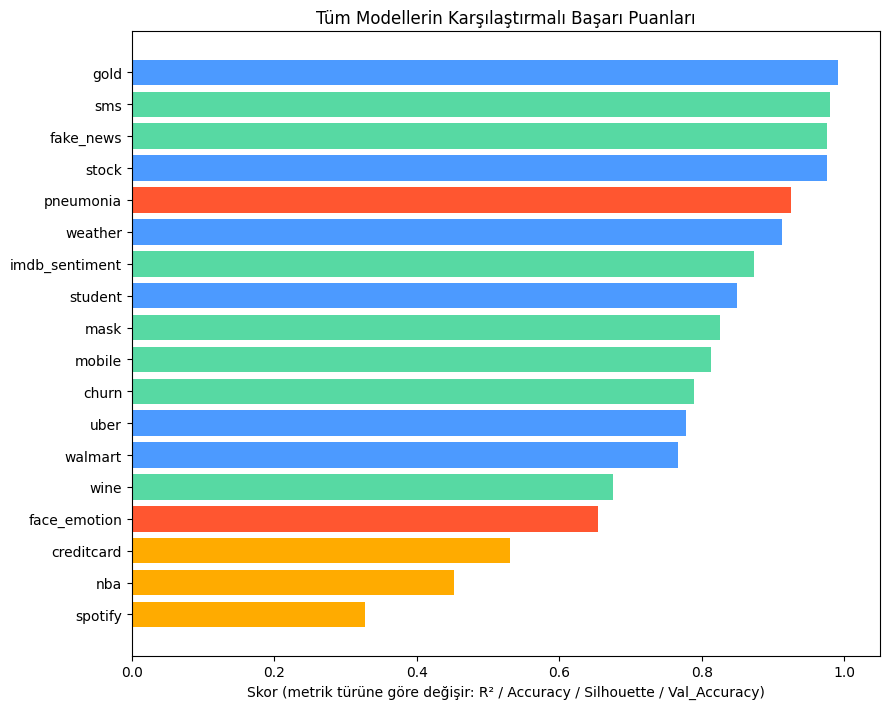


💾 models/metrics.json, models/metrics_summary.csv ve models/metrics_summary.png kaydedildi.
🏁 Notebook tamamlandı — app.py bu dosyaları otomatik okuyacak.


In [40]:
import matplotlib.pyplot as plt

with open('models/metrics.json', 'r', encoding='utf-8') as f:
    final_metrics = json.load(f)

rows = []
for key, m in final_metrics.items():
    mtype = m.get("type")
    if mtype == "regression":
        rows.append({"Proje": key, "Tip": "Regresyon", "Skor": m["R2"], "Skor Adı": "R²"})
    elif mtype == "classification":
        rows.append({"Proje": key, "Tip": "Sınıflandırma", "Skor": m["Accuracy"], "Skor Adı": "Accuracy"})
    elif mtype == "clustering":
        rows.append({"Proje": key, "Tip": "Kümeleme", "Skor": m["Silhouette"], "Skor Adı": "Silhouette"})
    elif mtype == "deep_learning":
        rows.append({"Proje": key, "Tip": "Derin Öğrenme", "Skor": m["Val_Accuracy"], "Skor Adı": "Val_Accuracy"})
    elif mtype == "error":
        rows.append({"Proje": key, "Tip": "❌ HATA", "Skor": None, "Skor Adı": m.get("error", "")[:40]})
    else:
        rows.append({"Proje": key, "Tip": "Metriksiz", "Skor": None, "Skor Adı": "-"})

summary_df = pd.DataFrame(rows)
summary_df.to_csv('models/metrics_summary.csv', index=False)

print(f"📊 Toplam {len(summary_df)} proje işlendi "
      f"({(summary_df['Tip'] == '❌ HATA').sum()} hata, "
      f"{summary_df['Skor'].notna().sum()} ölçülebilir skor).\n")

display(summary_df)

# --- Karşılaştırmalı bar grafiği (sadece ölçülebilir skorlar) ---
plot_df = summary_df.dropna(subset=["Skor"]).sort_values("Skor", ascending=True)

if len(plot_df) > 0:
    colors = plot_df["Tip"].map({
        "Regresyon": "#4C9AFF", "Sınıflandırma": "#57D9A3",
        "Kümeleme": "#FFAB00", "Derin Öğrenme": "#FF5630",
    }).fillna("#8993A4")

    fig, ax = plt.subplots(figsize=(9, max(4, len(plot_df) * 0.4)))
    ax.barh(plot_df["Proje"], plot_df["Skor"], color=colors)
    ax.set_xlabel("Skor (metrik türüne göre değişir: R² / Accuracy / Silhouette / Val_Accuracy)")
    ax.set_title("Tüm Modellerin Karşılaştırmalı Başarı Puanları")
    ax.set_xlim(0, 1.05 if plot_df["Skor"].max() <= 1 else None)
    plt.tight_layout()
    plt.savefig('models/metrics_summary.png', dpi=120)
    plt.show()

print("\n💾 models/metrics.json, models/metrics_summary.csv ve models/metrics_summary.png kaydedildi.")
print("🏁 Notebook tamamlandı — app.py bu dosyaları otomatik okuyacak.")

## ***11-Tüm Modelleri İndirme***

Aşağıdaki hücre, eğitilen tüm modelleri, ölçekleyicileri, vektörleştiricileri ve metrik dosyalarını tek bir `models_bundle.zip` arşivinde toplar. Google Colab'da otomatik indirme başlar; yerel Jupyter'da dosya yolu yazdırılır.

In [41]:
# ====================================================================
# 📦 TÜM MODELLERİ TEK ZIP DOSYASINDA İNDİRME
# Eğitilen tüm modeller, ölçekleyiciler, vektörleştiriciler ve metrik
# dosyaları 'models_bundle.zip' içinde toplanır.
# ====================================================================
import shutil
import os

zip_path = 'models_bundle'
shutil.make_archive(zip_path, 'zip', 'models')
zip_file = zip_path + '.zip'

boyut_mb = os.path.getsize(zip_file) / (1024 * 1024)
dosya_sayisi = len(os.listdir('models'))
print(f"✅ Arşiv oluşturuldu: {zip_file}")
print(f"   📁 {dosya_sayisi} dosya  |  💾 {boyut_mb:.2f} MB")

# Google Colab ortamındaysa otomatik indirme başlat
try:
    from google.colab import files
    files.download(zip_file)
    print("⬇️ İndirme başladı (Colab).")
except ImportError:
    print(f"ℹ️ Yerel ortam: dosyayı şu yoldan indirebilirsiniz -> {os.path.abspath(zip_file)}")


✅ Arşiv oluşturuldu: models_bundle.zip
   📁 40 dosya  |  💾 90.75 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️ İndirme başladı (Colab).
